In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, minimize_scalar
from scipy.signal import find_peaks
import matplotlib.patches as patches
import time
import ast
import pandas as pd
import os

# Functions

In [2]:
def dneff_w(width, a, b):
    '''Function to model the variation of effective index with waveguide width.

    Inputs:
    - width: array of waveguide widths (um)
    - a, b: fitting parameters

    Outputs:
    - dneff: array of effective index variations corresponding to the input widths
    '''
    # Variation of effective index with waveguide width
    width_0 = 1.0
    dneff = a*(width - width_0)**2 + b*(width - width_0)
    return dneff

def neff_wl(wavelength, a, b, c):
    '''Function to model the variation of effective index with wavelength.

    Inputs:
    - wavelength: array of wavelengths (nm)
    - a, b, c: fitting parameters

    Outputs:
    - neff: array of effective indices corresponding to the input wavelengths
    '''
    # Variation of effective index with wavelength
    wl_0 = 1550
    neff = a - b*(wavelength - wl_0) - c*(wavelength - wl_0)**2
    return neff

def neff_model(wavelength_train, width_train, dneff_train, neff_train, width_test, wavelength_test, neff_valid):
    '''Function to model the effective index variation with wavelength and waveguide width.

    Inputs:
    - wavelength_train: array of training wavelengths (nm)
    - width_train: array of training waveguide widths (um)
    - dneff_train: array of training effective index variations
    - neff_train: array of training effective indices
    - width_test: array of test waveguide widths (um)
    - wavelength_test: array of test wavelengths (nm)
    - neff_valid: array of validation effective indices

    Outputs:
    - mse: mean squared error between predicted and validation effective indices
    - neff_test2: array of predicted effective indices for the test data
    - popt_w: optimized parameters for the effective index as a function of waveguide width
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    '''
    width_0 = 1.0
    wl_0 = 1550

    p0_w = [0, 0]
    limits_w = ([-np.inf, -np.inf], [np.inf, np.inf])
    popt_w, pcov_w = curve_fit(dneff_w, width_train, dneff_train, bounds = limits_w, p0=p0_w, maxfev = int(1e5))

    p0_wl = [1.54, 0, 0]
    limits_wl = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    popt_wl, pcov_wl = curve_fit(neff_wl, wavelength_train, neff_train, bounds = limits_wl, p0=p0_wl, maxfev = int(1e5))

    neff_test = neff_wl(wavelength_train, *popt_wl) + dneff_w(width_test, *popt_w)
    mse = np.mean((neff_valid - neff_test)**2)

    neff_test2 = neff_wl(wavelength_test, *popt_wl) + dneff_w(width_test, *popt_w)

    # print(f'neff (λ [nm]) = {popt_wl[0]:.5f} - {popt_wl[1]:.5f}*(λ - {wl_0}) - ({popt_wl[2]:.5e}*(λ - {wl_0})^2)')
    # print(f'Δneff (w [μm]) = {popt_w[0]:.5f}*(w - {width_0})^2 + {popt_w[1]:.5f}*(w - {width_0})')

    return mse, neff_test2, popt_w, popt_wl

def open_file_modesolver(file_path, mode=0):
    ''' Function to open and read mode solver data from a file.

    Inputs:
    - file_path: path to the file containing mode solver data
    - mode: mode number to extract (default is 0, TE0 mode)

    Outputs:
    - wavelength: array of wavelengths
    - n_eff: array of effective indices
    '''
    with open(file_path, 'r') as f:
        first_line = f.readline()

    wl, index, neff = np.loadtxt(file_path, skiprows=1, usecols=(0, 1, 2), dtype=complex, unpack=True)
    filter = (index == mode)
    
    # Load wavelength and effective index
    wavelength, n_eff = wl[filter].real, neff[filter].real

    return wavelength, n_eff

def C_matrix(wavelength, neff, dz):
    '''Function to calculate the propagation matrix for a given wavelength, effective index, and step size.

    Inputs:
    - wavelength: wavelength of light (m)
    - neff: effective index of the waveguide
    - dz: step size along the waveguide (m)
    '''
    C = np.zeros((2, 2), dtype=complex)
    phase = 2*np.pi*neff/wavelength * dz
    C[0,0] = np.exp(1j * phase)
    C[1,1] = np.exp(-1j * phase)
    return C

def I_matrix(neff_1, neff_2):
    '''Function to calculate the interface matrix for two effective indices.
    
    Inputs:
    - neff_1: effective index of the first waveguide section
    - neff_2: effective index of the second waveguide section
    '''
    I = np.zeros((2, 2))
    I[0,0] = neff_1 + neff_2
    I[1,1] = I[0,0]
    I[0,1] = neff_2 - neff_1
    I[1,0] = I[0,1]
    I = (1/(2*np.sqrt(neff_1 * neff_2)))*I
    return I

def Bragg_grating(wavelength, w_array, dz, N, popt_wl, popt_w):
    '''Function to calculate the transfer matrix for a Bragg grating over a range of wavelengths and waveguide widths.

    Inputs:
    - wavelength: array of wavelengths to calculate the transfer matrix for (m)
    - w_array: array of waveguide widths along the grating (m)
    - dz: step size along the grating (m)
    - N: number of steps along the grating
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    - popt_w: optimized parameters for the effective index as a function of waveguide width

    Outputs:
    - M_T: list of transfer matrices for each wavelength
    '''
    M_T = []

    for wl in wavelength:
        M = np.eye(2, dtype=complex)
        neff = []

        for w in w_array:
            n = neff_wl(wl*1e9, *popt_wl) + dneff_w(w, *popt_w)
            neff.append(n)
        
        for i in range(N-1):
            I = I_matrix(neff[i], neff[i+1])
            C = C_matrix(wl, neff[i+1], dz)
            M @= I @ C
        
        M_T.append(M)

    return M_T

def Bragg_grating_mod(wavelength, w_array, dz, N, popt_wl, popt_w, delta_n):
    '''Function to calculate the transfer matrix for a Bragg grating over a range of wavelengths and waveguide widths.

    Inputs:
    - wavelength: array of wavelengths to calculate the transfer matrix for (m)
    - w_array: array of waveguide widths along the grating (m)
    - dz: step size along the grating (m)
    - N: number of steps along the grating
    - popt_wl: optimized parameters for the effective index as a function of wavelength
    - popt_w: optimized parameters for the effective index as a function of waveguide width
    - delta_n: overall experimental refractive index shift

    Outputs:
    - M_T: list of transfer matrices for each wavelength
    '''
    M_T = []

    for wl in wavelength:
        M = np.eye(2, dtype=complex)
        neff = []

        for w in w_array:
            n = neff_wl(wl*1e9, *popt_wl) + dneff_w(w, *popt_w) + delta_n
            neff.append(n)
        
        for i in range(N-1):
            I = I_matrix(neff[i], neff[i+1])
            C = C_matrix(wl, neff[i+1], dz)
            M @= I @ C
        
        M_T.append(M)

    return M_T

def uniform_grating(period, dwidth_2, N, duty, dL):
    '''Function to generate a uniform grating with specified parameters.

    Inputs:
    - period: grating period (m)
    - dwidth_2: corrugation of the second section of the grating (m)
    - N: number of periods in the grating
    - duty: duty cycle of the grating (fraction of the period occupied by the first section)
    - dL: length of the grating (m)

    Outputs:
    - z_real: array of positions along the grating (m)
    - dw_real_p: array of width variations for the positive section of the grating (um)
    - dw_real_n: array of width variations for the negative section of the grating (um)
    '''
    resolution = 500*N # Number of points to represent the grating
    L = period*N
    
    z_real = np.linspace(0, L, resolution)
    dw_real_p = np.where((z_real % period) < (period*duty), 0.0, dwidth_2) # Width variations for the positive section
    dw_real_n = -np.where(((z_real - dL) % period) < (period*duty), 0.0, dwidth_2) # Width variations for the negative section
    return z_real, np.array(dw_real_p), np.array(dw_real_n)

def grating_geometry(z_real, w_real_p, w_real_n, M):
    '''Function to calculate the mean width of the grating in M steps along the z direction.
    
    Inputs:
    - z_real: array of positions along the grating (m)
    - w_real_p: array of width variations for the positive section of the grating (um)
    - w_real_n: array of width variations for the negative section of the grating (um)
    - M: number of steps to divide the grating into
    
    Outputs:
    - z_edges: array of edges of the M steps along the z direction (m)
    - w_mean_p: array of mean widths for the positive section of the grating in each step (um)
    - w_mean_n: array of mean widths for the negative section of the grating in each step (um)
    '''
    # Calculate the mean width of the grating in M steps along the z direction
    L = max(z_real)

    z_edges = np.linspace(0, L, M + 1) 
    w_mean_p = []
    w_mean_n = []
    z_center = []

    for i in range(M):
        z_min = z_edges[i]
        z_max = z_edges[i+1]
        
        mask = (z_real >= z_min) & (z_real < z_max)
        
        step_mean_width_p = np.mean(w_real_p[mask])
        w_mean_p.append(step_mean_width_p)

        step_mean_width_n = np.mean(w_real_n[mask])
        w_mean_n.append(step_mean_width_n)
        
        z_center.append((z_min + z_max) / 2)

    return z_edges, np.array(w_mean_p), np.array(w_mean_n)

def prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor):
    '''Function to apply a Gaussian filter to the grating width variations and scale by a loss factor.
    
    Inputs:
    - z_real: array of positions along the grating (m)
    - sigma: standard deviation of the Gaussian filter (m)
    - dw_real_p: array of width variations for the positive section of the grating (um)
    - dw_real_n: array of width variations for the negative section of the grating (um)
    - scale_factor: scaling factor to account for losses in the grating
    
    Outputs:
    - dw_fab_p: array of filtered and scaled width variations for the positive section of the grating (um)
    - dw_fab_n: array of filtered and scaled width variations for the negative section of the grating (um)
    '''
    dz = z_real[1] - z_real[0]

    z_kernel = np.arange(-4*sigma, 4*sigma, dz)
    gaussian_kernel = (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-z_kernel**2/(2*sigma**2))
    gaussian_kernel /= np.sum(gaussian_kernel)

    dw_fab_p = np.convolve(dw_real_p, gaussian_kernel, mode='same')
    dw_fab_n = np.convolve(dw_real_n, gaussian_kernel, mode='same')

    dw_fab_p *= scale_factor
    dw_fab_n *= scale_factor

    return dw_fab_p, dw_fab_n

def find_minima(power, wavelength, threshold, separation):
    '''Function to find minima in the power spectrum.

    Inputs:
    - power: array of power values
    - wavelength: array of wavelength values
    - threshold: minimum prominence of the peaks
    - separation: minimum distance between peaks

    Outputs:
    - indices: array of indices of the found minima
    '''
    power_inverted = -power

    # Calculate average step size in wavelength and convert separation from nm to number of points based on average step size
    avg_step = np.mean(np.diff(wavelength)) 
    dist_points = int(separation/avg_step) 

    indices, properties = find_peaks(power_inverted, prominence=threshold, distance=dist_points)

    return indices

def find_minima_sides(wavelength, transmittance, distance):
    wavelength = np.asarray(wavelength)
    transmittance = np.asarray(transmittance)

    idx_min = np.argmin(transmittance)
    left_trans = transmittance[:idx_min]

    left_peaks, _ = find_peaks(left_trans, distance=distance)
    if len(left_peaks) > 0:
        idx_peak_left = left_peaks[-1]
        wl_left = wavelength[idx_peak_left]
    else:
        wl_left, idx_peak_left = None, None

    right_trans = transmittance[idx_min:]

    right_peaks, _ = find_peaks(right_trans, distance=distance)
    if len(right_peaks) > 0:
        idx_peak_right = right_peaks[0] + idx_min
        wl_right = wavelength[idx_peak_right]
    else:
        wl_right, idx_peak_right = None, None

    return [idx_peak_left, idx_peak_right], [wl_left, wl_right]

In [3]:
def open_file(file_path, print_header=False):
    """Function to open OSA data file, extract header information and load wavelength and power data.

    Inputs:
    - file_path: path to the OSA data file
    - print_header: boolean to indicate whether to print header information (default: False)

    Outputs:
    - wavelength: array of wavelength values
    - power: array of power values (adjusted for splitter loss)

    Notes:
    - The function assumes that the splitter header information is in the format "1x2-50/50" (input x output - OSA/OPM) and calculates the
    splitter loss accordingly. If the splitter is "na", it assumes no splitter loss."""

    # Open file
    with open(file_path, 'r') as f:
        first_line = f.readline()

    # Obtain header information 
    header_str = first_line[first_line.find("{"):].strip() 
    header_dict = ast.literal_eval(header_str)
    
    # Print header information
    if print_header:
        print("#"*90)
        print("FILE DATA:")
        print("#"*90)
        for key, value in header_dict.items():
            print(f"{key}: {value}")

    # Calculate splitter loss and adjustment power values
    if header_dict['splitter'] == 'na':
        splitter_opm_loss = 0
        splitter_osa_loss = 0
    
    # For a format like "1x2-50/50" (input x output - OSA/OPM)
    else:
        splitter_loss = header_dict['splitter'].split('-')[-1].split('/')
        splitter_opm_loss = 10*np.log10(float(splitter_loss[1])/100)
        splitter_osa_loss = 10*np.log10(float(splitter_loss[0])/100)

    # Load wavelength and power data
    wavelength, power = np.loadtxt(file_path, comments='%', unpack=True)
    wavelength = wavelength.astype('float')
    power = power.astype('float')

    return wavelength, power - splitter_osa_loss

def filter_wavelength(wavelength, power, wl_0, wl_1):
    """Function to filter wavelength to a desired region.

    Inputs:
    - wavelength: array of wavelength values
    - power: array of power values
    - wl_0: lower bound of the wavelength region
    - wl_1: upper bound of the wavelength region

    Outputs:
    - wavelength: array of filteredwavelength values
    - power: array of filteredpower values"""

    wavelength_filtered = wavelength[(wavelength >= wl_0) & (wavelength < wl_1)]
    power_filtered = power[(wavelength >= wl_0) & (wavelength < wl_1)]
    
    return wavelength_filtered, power_filtered

def find_minima(power, wavelength, threshold, separation):
    '''Function to find minima in the power spectrum.

    Inputs:
    - power: array of power values
    - wavelength: array of wavelength values
    - threshold: minimum prominence of the peaks
    - separation: minimum distance between peaks

    Outputs:
    - indices: array of indices of the found minima
    '''

    power_inverted = -power

    # Calculate average step size in wavelength and convert separation from nm to number of points based on average step size
    avg_step = np.mean(np.diff(wavelength)) 
    dist_points = int(separation/avg_step) 

    indices, properties = find_peaks(power_inverted, prominence=threshold, distance=dist_points)

    return indices

def get_resonance(idx, wavelength_dut, power_dut, power_wg, window_size, fc, threshold, separation):
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)

    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min = wavelength_dut[indices]
    power_diff_min = power_diff[indices]

    # Windowing
    wl_0 = wl_min[idx] - window_size/2
    wl_1 = wl_min[idx] + window_size/2
    wavelength_zoom, power_zoom = filter_wavelength(wavelength_dut, power_diff, wl_0, wl_1)

    # Fourier Transform
    step = wavelength_zoom[1] - wavelength_zoom[0]
    fs = 1 / step

    power_zoom_fft = np.fft.fft(10**(power_zoom/10))
    freq = np.fft.fftfreq(len(wavelength_zoom), 1/fs)
    filter = np.abs(freq) < fc
    power_zoom_fft_filtered = power_zoom_fft * filter
    power_zoom_ifft = -10*np.log10(np.abs(np.fft.ifft((power_zoom_fft_filtered))))
    power_zoom_ifft = -power_zoom_ifft
    power_ifft_max = np.max(power_zoom_ifft)

    power_zoom_ifft = power_zoom_ifft - power_ifft_max
    power_zoom = power_zoom - power_ifft_max

    return wavelength_zoom, power_zoom, power_zoom_ifft

def plot_spectra(wavelength_dut, power_dut, power_wg, threshold, separation, dut_name):
    #####################################################################################################################
    # Function to plot the spectra of the DUT and difference with reference waveguide, including minima points
    # Inputs:
    # - wavelength: array of wavelength values
    # - power: array of power values
    # - wl_0: lower bound of the wavelength region
    # - wl_1: upper bound of the wavelength region
    # Outputs:
    # - wl_min: array of wavelength values corresponding to the found minima
    #####################################################################################################################

    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    if np.max(power_diff) > 0:
        power_diff = power_diff - np.max(power_diff)
    
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)

    wl_min = wavelength_dut[indices]
    power_min = power_dut[indices]
    power_diff_min = power_diff[indices]

    plt.figure(figsize=(8, 4))
    plt.plot(wavelength_dut, power_dut, label='DUT')

    plt.plot(wavelength_dut, power_wg, color='gray', linestyle='--', alpha=0.5, label='Reference Waveguide')
    plt.scatter(wl_min, power_min, color='red', label='Minima')

    # Plot measured spectrum
    for i in range(len(wl_min)):
        plt.annotate(i, (wl_min[i], power_min[i]), textcoords="offset points", xytext=(0,-20), ha='center', color='red')

    plt.title(f"{dut_name}: Optical Spectrum")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Power (dBm)")
    plt.legend(fontsize=9)
    plt.grid()
    plt.show()

    # # Plot difference with reference waveguide
    # plt.figure(figsize=(8, 4))
    # plt.plot(wavelength_dut, power_diff, label='DUT')
    # plt.scatter(wl_min, power_diff_min, color='red', label='Minima')

    # for i in range(len(wl_min)):
    #     plt.annotate(i, (wl_min[i], power_diff_min[i]), textcoords="offset points", xytext=(0,-20), ha='center', color='red')

    # plt.title(f"{dut_name}: Optical Spectrum Difference")
    # plt.xlabel("Wavelength (nm)")
    # plt.ylabel("Power (dBm)")
    # plt.legend(fontsize=9)
    # plt.grid()
    # plt.show()

    # print(f"Minimums found in {dut_name} at wavelengths: {wl_min} nm")

    return wl_min

def fourier_test(idx, wavelength_dut, power_dut, power_wg, window_size, fc, threshold, separation):
    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_dut, power_dut, power_wg, 2*window_size, fc, threshold, separation)

    plt.plot(wavelength_zoom, power_zoom, label='Measured')
    plt.plot(wavelength_zoom, power_zoom_ifft, label='Reconstructed')
    plt.xlabel("Wavelength (nm)", fontsize=12)
    plt.ylabel("Power (dBm)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(which='both', alpha=0.5)
    plt.show()

    return None

def reflectivity(wavelength_dut, power_dut, power_wg, window_size, fc, threshold, separation):
    power_diff = power_dut - power_wg
    if np.max(power_diff) > 0:
        power_diff = power_diff - np.max(power_diff)
    
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min_array = wavelength_dut[indices]

    T = np.zeros(len(wl_min_array))
    BW = np.zeros(len(wl_min_array))
    wl = np.zeros(len(wl_min_array))
    
    for idx in range(len(wl_min_array)):
        wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_dut, power_dut, power_wg, window_size, fc, threshold, separation)

        idx_min, wl_min = find_minima_sides(wavelength_zoom, power_zoom_ifft, distance=2)
        bw_measure = np.abs(wl_min[0] - wl_min[1])
        power_min_ifft = min(power_zoom_ifft)
        wl_min_ifft = wavelength_zoom[np.argmin(power_zoom_ifft)]

        T[idx] = 10**(power_min_ifft/10)
        wl[idx] = wl_min_ifft
        BW[idx] = bw_measure

    R = 1-T
    return wl, R, BW

def shift_analysis(original_wl, measured_wl, period_array):
    ###########################################################################################################################
    # Function to calculate the shifted resonance respect to design, and the corresponding shift in effective index
    # Inputs:
    # - original_wl: array of original wavelength values corresponding to the design
    # - measured_wl: array of measured wavelength values corresponding to the found minima
    # - n_avg: array of effective indices of the waveguide
    # Outputs:
    # - lambda_shift: array of wavelength shifts corresponding to each minimum
    # - n_shift: array of effective index shifts corresponding to each minimum
    ###########################################################################################################################

    n = len(original_wl)-len(measured_wl)

    lambda_shift = original_wl[n:] - measured_wl
    n_shift = -(original_wl[n:]-measured_wl)/(2*np.array(period_array[n:]))*1e-9
    return lambda_shift, n_shift

In [4]:
def run_tmm_simulation_scale(scale_factor, i, z_real, dw_real_p, dw_real_n, M_fab, 
                       width_0, wl_min_real, window_size, popt_wl, popt_w, delta_n):
    """
    Ejecuta la simulación TMM para un scale_factor dado
    y devuelve la longitud de onda de mínima transmisión simulada (wl_min_pred).
    """

    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma_0, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_fab)
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

    wavelength_test = (np.arange(wl_min_real - window_size, wl_min_real + window_size, 0.125)) * 1e-9
    dz = L/ M_fab
    
    M_wl = Bragg_grating_mod(wavelength_test, w_mean_fab, dz, M_fab, popt_wl, popt_w, delta_n)

    T_fab = np.zeros(len(wavelength_test))
    for j in range(len(wavelength_test)):
        T_fab[j] = 1 / (np.abs(M_wl[j][0, 0])**2)

    T_fab_dB = 10 * np.log10(T_fab)
    min_T_dB = np.min(T_fab_dB)

    idx_min = np.argmin(T_fab)
    wl_min_pred = wavelength_test[idx_min]
    
    return min_T_dB, wl_min_pred, T_fab, wavelength_test

# Objective class
class ScaleOptimizationTracker:
    def __init__(self, power_min_ifft, wl_min_ifft, i, z_real, dw_real_p, dw_real_n, M_fab, 
                 width_0, wl_min_real, window_size, popt_wl, popt_w, delta_n):
        self.power_min_ifft = power_min_ifft
        self.wl_min_ifft = wl_min_ifft
        self.i = i
        self.z_real = z_real
        self.dw_real_p = dw_real_p
        self.dw_real_n = dw_real_n
        self.M_fab = M_fab
        self.width_0 = width_0
        self.wl_min_real = wl_min_real
        self.window_size = window_size
        self.popt_wl = popt_wl
        self.popt_w = popt_w
        self.delta_n = delta_n
        
        self.iteration = 0

    def __call__(self, sf_candidate):
        self.iteration += 1
        t0 = time.perf_counter()

        min_T_dB, wl_min_pred, _, _ = run_tmm_simulation_scale(
            scale_factor=sf_candidate,
            i=self.i,
            z_real=self.z_real,
            dw_real_p=self.dw_real_p,
            dw_real_n=self.dw_real_n,
            M_fab=self.M_fab,
            width_0=self.width_0,
            wl_min_real=self.wl_min_real,
            window_size=self.window_size,
            popt_wl=self.popt_wl,
            popt_w=self.popt_w,
            delta_n=self.delta_n
        )
        
        # Control parameter
        d_T = self.power_min_ifft - min_T_dB
        d_wl = self.wl_min_ifft*1e-9 - wl_min_pred
        error_sq = d_wl**2

        t1 = time.perf_counter()
        elapsed_time = t1 - t0

        print(f"Iteration {self.iteration:2d} | "
              f"Scale Factor (γ): {sf_candidate:.5f} | "
              f"Δλ: {d_wl * 1e9:6.5f} nm | "
              f"ΔT: {d_T:6.5f} dB | "
              f"Time: {elapsed_time:.3f} s")

        return error_sq

def run_tmm_simulation_sigma(sigma_candidate, scale_factor, i, z_real, dw_real_p, dw_real_n, 
                             M_fab, width_0, wl_min_real, window_size, popt_wl, popt_w, delta_n):
    """
    Ejecuta la simulación TMM evaluando un valor específico de sigma
    y obtiene el valor mínimo de transmisión en dB.
    """

    dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma_candidate, dw_real_p, dw_real_n, scale_factor)
    z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_fab)
    w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

    wavelength_test = (np.arange(wl_min_real - window_size, wl_min_real + window_size, 0.125)) * 1e-9
    dz = L/M_fab
    
    M_wl = Bragg_grating_mod(wavelength_test, w_mean_fab, dz, M_fab, popt_wl, popt_w, delta_n)

    T_fab = np.zeros(len(wavelength_test))
    for j in range(len(wavelength_test)):
        T_fab[j] = 1 / (np.abs(M_wl[j][0, 0])**2)

    T_fab_dB = 10 * np.log10(T_fab)
    min_T_dB = np.min(T_fab_dB)

    idx_min = np.argmin(T_fab)
    wl_min_pred = wavelength_test[idx_min]
    
    return min_T_dB, wl_min_pred, T_fab_dB, wavelength_test

# Objective class
class SigmaOptimizationTracker:
    def __init__(self, power_min_ifft, wl_min_ifft, scale_factor, i, z_real, dw_real_p, dw_real_n, 
                 M_fab, width_0, wl_min_real, window_size, popt_wl, popt_w, delta_n):
        self.power_min_ifft = power_min_ifft
        self.wl_min_ifft = wl_min_ifft
        self.scale_factor = scale_factor
        self.i = i
        self.z_real = z_real
        self.dw_real_p = dw_real_p
        self.dw_real_n = dw_real_n
        self.M_fab = M_fab
        self.width_0 = width_0
        self.wl_min_real = wl_min_real
        self.window_size = window_size
        self.popt_wl = popt_wl
        self.popt_w = popt_w
        self.delta_n = delta_n
        
        self.iteration = 0

    def __call__(self, sigma_candidate):
        self.iteration += 1
        t0 = time.perf_counter()

        min_T_dB, wl_min_pred,  _, _ = run_tmm_simulation_sigma(
            sigma_candidate=sigma_candidate,
            scale_factor=self.scale_factor,
            i=self.i,
            z_real=self.z_real,
            dw_real_p=self.dw_real_p,
            dw_real_n=self.dw_real_n,
            M_fab=self.M_fab,
            width_0=self.width_0,
            wl_min_real=self.wl_min_real,
            window_size=self.window_size,
            popt_wl=self.popt_wl,
            popt_w=self.popt_w,
            delta_n=self.delta_n
        )

        # Control parameter
        d_T = self.power_min_ifft - min_T_dB
        d_wl = self.wl_min_ifft*1e-9 - wl_min_pred
        error_sq = d_T**2

        t1 = time.perf_counter()
        elapsed_time = t1 - t0

        print(f"Iteration {self.iteration:2d} | "
              f"σ: {sigma_candidate * 1e9:6.3f} nm | "
              f"ΔT: {d_T:6.5f} dB | "
              f"Δλ: {d_wl*1e9:6.5f} nm | "
              f"Time: {elapsed_time:.3f} s")

        return error_sq

# Initialization

In [5]:
material = 'BCB'
wl_center = 1550

# U1 design parameters
N_u1 = 1000
wl_u1 = (np.arange(8)-3)*10 + wl_center

# U2 design parameters
N_u2 = 2000
wl_u2 = (np.arange(6)-2)*10 + wl_center

# U3 design parameters
N_u3 = 4000
wl_u3 = (np.arange(4)-2)*10 + wl_center

width_0 = 1.0 # Nominal Width of the waveguide (um)
width = np.round(width_0 + np.arange(0, 9)*0.05, 2) # Waveguide width list (um)
dwidth = (width - width_0)/2 # Corrugation list (um)

In [6]:
equipment = 'YOKO'
gratings = 'uniform'

# Laser range
d_wl = 4
wl_0 = 1530 - d_wl 
wl_1 = 1600 + d_wl


## Design

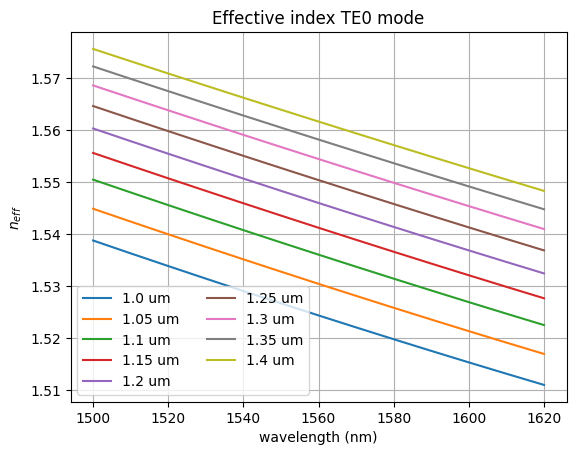

In [7]:
# Extract Effective Indices from Modesolver results
dneff = []
n_eff = []

file_path = f"/home/arjoa/UPVfab/upvfab-design-tools/results/{material}/1.0um/modesolver_results_1.0um.txt"
wavelength_0, neff_0 = open_file_modesolver(file_path)

for w in width:
    file_path = f"/home/arjoa/UPVfab/upvfab-design-tools/results/{material}/{w}um/modesolver_results_{w}um.txt"
    wavelength, neff = open_file_modesolver(file_path)

    dneff.append(np.mean(neff - neff_0))
    n_eff.append(neff)
    plt.plot(wavelength, neff, label=f'{w} um')

plt.title('Effective index TE0 mode')
plt.xlabel('wavelength (nm)')
plt.ylabel(r'$n_{eff}$')
plt.grid()
plt.legend(ncols=2)
plt.show()

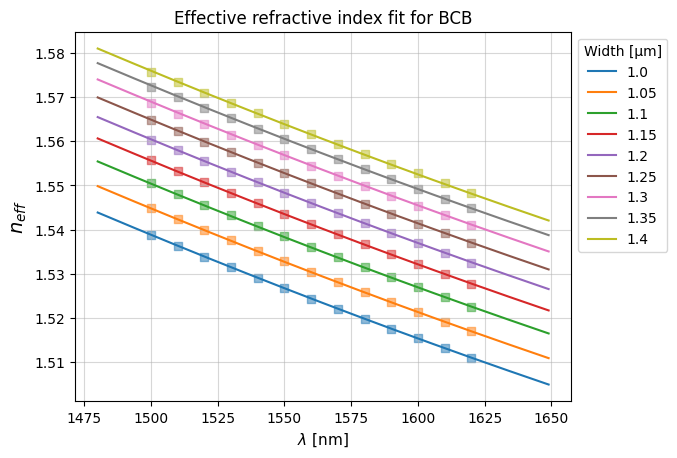

RMSE = 1.122e-04


In [8]:
# Create and effective index model for the waveguides as a funcion of wavelength and width
dneff_train = dneff
neff_train = n_eff[0]
wavelength_train = wavelength
width_train = width
mean_sq = []
wavelength_test = np.arange(1480, 1650, 1)

for i, w in enumerate(width):
    width_test = w
    neff_valid = n_eff[i]

    mse, neff_test, popt_w, popt_wl = neff_model(wavelength_train, width_train, dneff_train, neff_train, width_test, wavelength_test, neff_valid)
    mean_sq.append(mse)

    fit, = plt.plot(wavelength_test, neff_test, label = f'{width_test}')
    plt.scatter(wavelength, neff_valid, color = fit.get_color(), alpha=0.5, marker='s')
    
plt.title(fr'Effective refractive index fit for {material}')
plt.xlabel(r'$\lambda$ [nm]', fontsize=11)
plt.ylabel(r'$n_{eff}$', fontsize=14)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize = 10, title='Width [μm]', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

print(f'RMSE = {np.sqrt(np.mean(np.array(mean_sq))):.3e}')

U1 parameters 

λ   = [1520 1530 1540 1550 1560 1570 1580 1590] (nm)
ΔW  = [ 25.  50.  75. 100. 125. 150. 175. 200.] (nm)
Λ   = [494.5100947  497.64142118 500.82363834 504.05772417 507.34468885
 510.68557587 514.08146312 517.53346404] (nm)


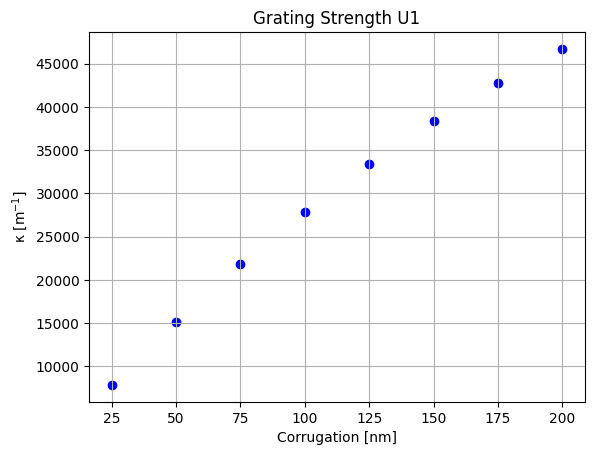

In [9]:
# Obtain the grating period for each U1 Bragg grating
period_array_u1 = []
n1_array = []
n2_array = []
n_avg_u1 = []

i = 1 # Start with a corrugation of 25 nm
for bragg_wl in wl_u1:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u1.append(float(n_avg))
    period_array_u1.append(float(period*1e-3))
    i+=1

print('U1 parameters \n')
print(f'λ   = {wl_u1} (nm)')
print(f'ΔW  = {(width[1:] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u1)*1e3} (nm)')

# Grating Strength Estimation
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u1 = 2*delta_n/((np.array(n1_array)  + np.array(n2_array))*np.array(period_array_u1)*1e-6)
plt.scatter((width[1:] - width_0)/2*1e3, kappa_u1, color='b')

plt.title('Grating Strength U1')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

U2 parameters 

λ   = [1530 1540 1550 1560 1570 1580] (nm)
ΔW  = [ 25.  50.  75. 100. 125. 150.] (nm)
Λ   = [498.54817136 501.67392744 504.8509589  508.08024049 511.36277939
 514.69961629] (nm)


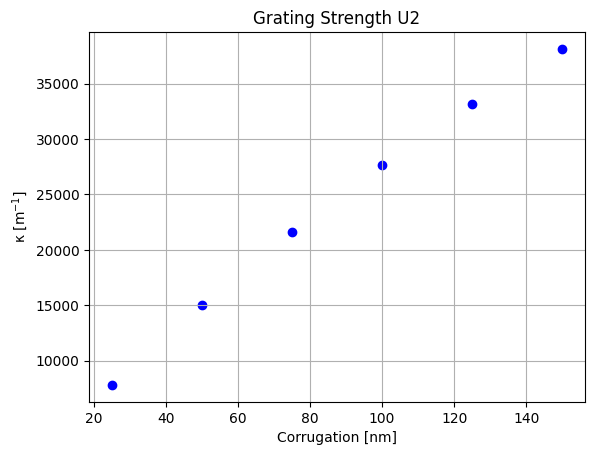

In [10]:
# Obtain the grating period for each U2 Bragg grating
period_array_u2 = []
n1_array = []
n2_array = []
n_avg_u2 = []

i = 1 # Start with a corrugation of 25 nm
for bragg_wl in wl_u2:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u2.append(float(n_avg))
    period_array_u2.append(float(period*1e-3))
    i+=1

print('U2 parameters \n')
print(f'λ   = {wl_u2} (nm)')
print(f'ΔW  = {(width[1:7] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u2)*1e3} (nm)')

# Grating Strength
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u2 = 2*delta_n/(wl_u2*1e-9)
plt.scatter((width[1:7] - width_0)/2*1e3, kappa_u2, color='b')

plt.title('Grating Strength U2')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

U3 parameters 

λ   = [1530 1540 1550 1560] (nm)
ΔW  = [ 50.  75. 100. 125.] (nm)
Λ   = [497.64142118 500.82363834 504.05772417 507.34468885] (nm)


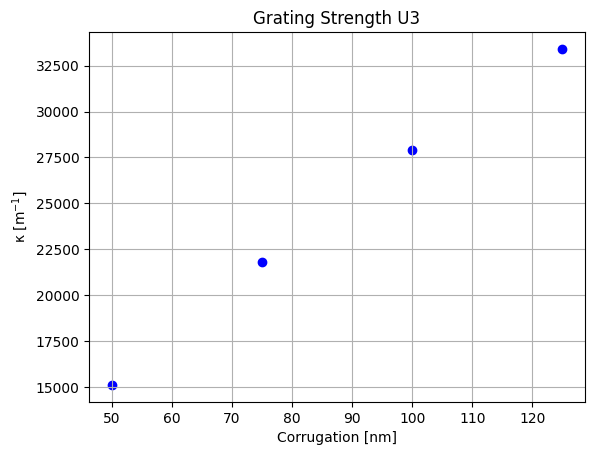

In [11]:
# Obtain the grating period for each U3 Bragg grating
period_array_u3 = []
n1_array = []
n2_array = []
n_avg_u3 = []

i = 2 # Start with a corrugation of 50 nm
for bragg_wl in wl_u3:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_u3.append(float(n_avg))
    period_array_u3.append(float(period*1e-3))
    i+=1

print('U3 parameters \n')
print(f'λ   = {wl_u3} (nm)')
print(f'ΔW  = {(width[2:6] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_u3)*1e3} (nm)')

# Grating Strength
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_u3 = 2*delta_n/(wl_u3*1e-9)
plt.scatter((width[2:6] - width_0)/2*1e3, kappa_u3, color='b')

plt.title('Grating Strength U3')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

## Characterization

In [12]:
if equipment == 'OSA20' and gratings == 'uniform':
    vs = 2.0 #nm/s (OSA20 sensitivity = 5.0)
    
    ##### Reference Waveguides ##############################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\wg.txt" 
    wavelength_wg_r2, power_wg_r2 = open_file(file_path)
    wavelength_wg_r2, power_wg_r2 = filter_wavelength(wavelength_wg_r2, power_wg_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\wg.txt"   
    wavelength_wg_r4, power_wg_r4 = open_file(file_path)
    wavelength_wg_r4, power_wg_r4 = filter_wavelength(wavelength_wg_r4, power_wg_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\wg.txt"   
    wavelength_wg_r7, power_wg_r7 = open_file(file_path)
    wavelength_wg_r7, power_wg_r7 = filter_wavelength(wavelength_wg_r7, power_wg_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\wg.txt"  
    wavelength_wg_r10, power_wg_r10 = open_file(file_path)
    wavelength_wg_r10, power_wg_r10 = filter_wavelength(wavelength_wg_r10, power_wg_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\wg.txt"  
    wavelength_wg_r12, power_wg_r12 = open_file(file_path)
    wavelength_wg_r12, power_wg_r12 = filter_wavelength(wavelength_wg_r12, power_wg_r12, wl_0, wl_1)

    ##### U1 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\u1.txt"   
    wavelength_u1_r2, power_u1_r2 = open_file(file_path)
    wavelength_u1_r2, power_u1_r2 = filter_wavelength(wavelength_u1_r2, power_u1_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\u1.txt"   
    wavelength_u1_r4, power_u1_r4 = open_file(file_path)
    wavelength_u1_r4, power_u1_r4 = filter_wavelength(wavelength_u1_r4, power_u1_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\u1.txt"   
    wavelength_u1_r7, power_u1_r7 = open_file(file_path)
    wavelength_u1_r7, power_u1_r7 = filter_wavelength(wavelength_u1_r7, power_u1_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\u1.txt"  
    wavelength_u1_r10, power_u1_r10 = open_file(file_path)
    wavelength_u1_r10, power_u1_r10 = filter_wavelength(wavelength_u1_r10, power_u1_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\u1.txt"   
    wavelength_u1_r12, power_u1_r12 = open_file(file_path)
    wavelength_u1_r12, power_u1_r12 = filter_wavelength(wavelength_u1_r12, power_u1_r12, wl_0, wl_1)

    ##### U2 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\u2.txt"   
    wavelength_u2_r2, power_u2_r2 = open_file(file_path)
    wavelength_u2_r2, power_u2_r2 = filter_wavelength(wavelength_u2_r2, power_u2_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\u2.txt" 
    wavelength_u2_r4, power_u2_r4 = open_file(file_path)
    wavelength_u2_r4, power_u2_r4 = filter_wavelength(wavelength_u2_r4, power_u2_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\u2.txt" 
    wavelength_u2_r7, power_u2_r7 = open_file(file_path)
    wavelength_u2_r7, power_u2_r7 = filter_wavelength(wavelength_u2_r7, power_u2_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\u2.txt" 
    wavelength_u2_r10, power_u2_r10 = open_file(file_path)
    wavelength_u2_r10, power_u2_r10 = filter_wavelength(wavelength_u2_r10, power_u2_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\u2.txt" 
    wavelength_u2_r12, power_u2_r12 = open_file(file_path)
    wavelength_u2_r12, power_u2_r12 = filter_wavelength(wavelength_u2_r12, power_u2_r12, wl_0, wl_1)

    ##### U3 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/2/5\u3.txt" 
    wavelength_u3_r2, power_u3_r2 = open_file(file_path)
    wavelength_u3_r2, power_u3_r2 = filter_wavelength(wavelength_u3_r2, power_u3_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/4/5\u3.txt"
    wavelength_u3_r4, power_u3_r4 = open_file(file_path)
    wavelength_u3_r4, power_u3_r4 = filter_wavelength(wavelength_u3_r4, power_u3_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/7/5\u3.txt" 
    wavelength_u3_r7, power_u3_r7 = open_file(file_path)
    wavelength_u3_r7, power_u3_r7 = filter_wavelength(wavelength_u3_r7, power_u3_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/10/5\u3.txt" 
    wavelength_u3_r10, power_u3_r10 = open_file(file_path)
    wavelength_u3_r10, power_u3_r10 = filter_wavelength(wavelength_u3_r10, power_u3_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4/12/5\u3.txt" 
    wavelength_u3_r12, power_u3_r12 = open_file(file_path)
    wavelength_u3_r12, power_u3_r12 = filter_wavelength(wavelength_u3_r12, power_u3_r12, wl_0, wl_1)

In [13]:
if equipment == 'YOKO' and gratings == 'uniform':
    
    ##### Reference Waveguides ##############################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\wg.txt" 
    wavelength_wg_r2, power_wg_r2 = open_file(file_path)
    wavelength_wg_r2, power_wg_r2 = filter_wavelength(wavelength_wg_r2, power_wg_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\wg.txt" 
    wavelength_wg_r4, power_wg_r4 = open_file(file_path)
    wavelength_wg_r4, power_wg_r4 = filter_wavelength(wavelength_wg_r4, power_wg_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\wg.txt" 
    wavelength_wg_r7, power_wg_r7 = open_file(file_path)
    wavelength_wg_r7, power_wg_r7 = filter_wavelength(wavelength_wg_r7, power_wg_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\wg.txt" 
    wavelength_wg_r10, power_wg_r10 = open_file(file_path)
    wavelength_wg_r10, power_wg_r10 = filter_wavelength(wavelength_wg_r10, power_wg_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\wg.txt" 
    wavelength_wg_r12, power_wg_r12 = open_file(file_path)
    wavelength_wg_r12, power_wg_r12 = filter_wavelength(wavelength_wg_r12, power_wg_r12, wl_0, wl_1)

    ##### U1 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u1.txt" 
    wavelength_u1_r2, power_u1_r2 = open_file(file_path)
    wavelength_u1_r2, power_u1_r2 = filter_wavelength(wavelength_u1_r2, power_u1_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u1.txt" 
    wavelength_u1_r4, power_u1_r4 = open_file(file_path)
    wavelength_u1_r4, power_u1_r4 = filter_wavelength(wavelength_u1_r4, power_u1_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u1.txt" 
    wavelength_u1_r7, power_u1_r7 = open_file(file_path)
    wavelength_u1_r7, power_u1_r7 = filter_wavelength(wavelength_u1_r7, power_u1_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u1.txt" 
    wavelength_u1_r10, power_u1_r10 = open_file(file_path)
    wavelength_u1_r10, power_u1_r10 = filter_wavelength(wavelength_u1_r10, power_u1_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u1.txt" # Read mode so \u... is not interpreted as unicode
    wavelength_u1_r12, power_u1_r12 = open_file(file_path)
    wavelength_u1_r12, power_u1_r12 = filter_wavelength(wavelength_u1_r12, power_u1_r12, wl_0, wl_1)

    ##### U2 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u2.txt" 
    wavelength_u2_r2, power_u2_r2 = open_file(file_path)
    wavelength_u2_r2, power_u2_r2 = filter_wavelength(wavelength_u2_r2, power_u2_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u2.txt" 
    wavelength_u2_r4, power_u2_r4 = open_file(file_path)
    wavelength_u2_r4, power_u2_r4 = filter_wavelength(wavelength_u2_r4, power_u2_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u2.txt" 
    wavelength_u2_r7, power_u2_r7 = open_file(file_path)
    wavelength_u2_r7, power_u2_r7 = filter_wavelength(wavelength_u2_r7, power_u2_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u2.txt" 
    wavelength_u2_r10, power_u2_r10 = open_file(file_path)
    wavelength_u2_r10, power_u2_r10 = filter_wavelength(wavelength_u2_r10, power_u2_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u2.txt" 
    wavelength_u2_r12, power_u2_r12 = open_file(file_path)
    wavelength_u2_r12, power_u2_r12 = filter_wavelength(wavelength_u2_r12, power_u2_r12, wl_0, wl_1)

    ##### U3 ################################################################################################
    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u3.txt" 
    wavelength_u3_r2, power_u3_r2 = open_file(file_path)
    wavelength_u3_r2, power_u3_r2 = filter_wavelength(wavelength_u3_r2, power_u3_r2, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u3.txt" 
    wavelength_u3_r4, power_u3_r4 = open_file(file_path)
    wavelength_u3_r4, power_u3_r4 = filter_wavelength(wavelength_u3_r4, power_u3_r4, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u3.txt" 
    wavelength_u3_r7, power_u3_r7 = open_file(file_path)
    wavelength_u3_r7, power_u3_r7 = filter_wavelength(wavelength_u3_r7, power_u3_r7, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u3.txt" 
    wavelength_u3_r10, power_u3_r10 = open_file(file_path)
    wavelength_u3_r10, power_u3_r10 = filter_wavelength(wavelength_u3_r10, power_u3_r10, wl_0, wl_1)

    file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u3.txt" 
    wavelength_u3_r12, power_u3_r12 = open_file(file_path)
    wavelength_u3_r12, power_u3_r12 = filter_wavelength(wavelength_u3_r12, power_u3_r12, wl_0, wl_1)

# Characterization

In [14]:
# Measured power of the device
power_dut_u1 = [power_u1_r2, power_u1_r4, power_u1_r7, power_u1_r10, power_u1_r12]   
power_dut_u2 = [power_u2_r2, power_u2_r4, power_u2_r7, power_u2_r10, power_u2_r12]
power_dut_u3 = [power_u3_r2, power_u3_r4, power_u3_r7, power_u3_r10, power_u3_r12]   

# Measured power of the reference waveguide
power_wg = [power_wg_r2, power_wg_r4, power_wg_r7, power_wg_r10, power_wg_r12]     

# Wavelength range
wavelength_dut_u1 = [wavelength_u1_r2, wavelength_u1_r4, wavelength_u1_r7, wavelength_u1_r10, wavelength_u1_r12]    
wavelength_dut_u2 = [wavelength_u2_r2, wavelength_u2_r4, wavelength_u2_r7, wavelength_u2_r10, wavelength_u2_r12] 
wavelength_dut_u3 = [wavelength_u3_r2, wavelength_u3_r4, wavelength_u3_r7, wavelength_u3_r10, wavelength_u3_r12]  

separation = 10                         # Minimum separation between minima (nm)
window_size_2 = 10                      # Window centered at minima (nm) 
window_size_res = 5                     # Window to isolate the minima, and calculate the predicted response

dw_u1 = (width[1:] - width_0)/2*1e3
dw_u2 = (width[1:7] - width_0)/2*1e3
dw_u3 = (width[2:6] - width_0)/2*1e3

dw_measure_u1 = (width[4:] - width_0)/2*1e3
dw_measure_u2 = (width[3:7] - width_0)/2*1e3
dw_measure_u3 = (width[4:6] - width_0)/2*1e3

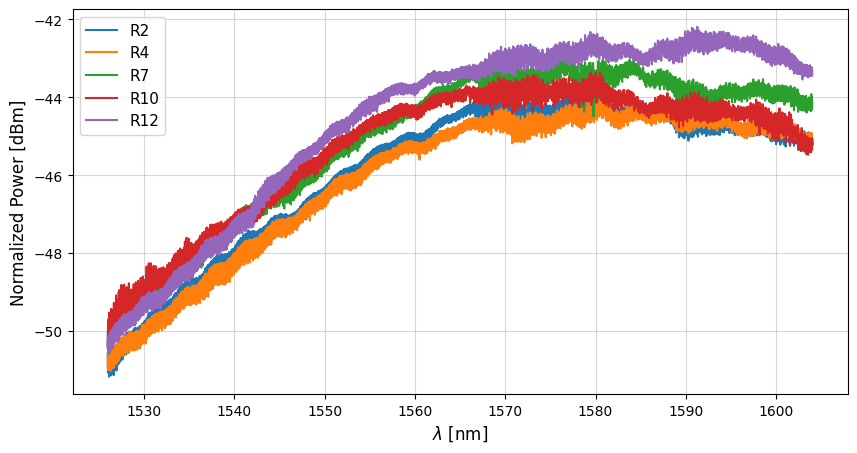

In [15]:
file_path= r"/home/arjoa/UPVfab/test_osa/data/MPWrun0/V053_1470/10/A6\laser.txt"
wavelength_laser, power_laser = open_file(file_path)
wavelength_laser, power_laser = filter_wavelength(wavelength_laser, power_laser, wl_0, wl_1)
power_laser_int = np.interp(wavelength_wg_r2, wavelength_laser, power_laser)

plt.figure(figsize=(10, 5))
plt.plot(wavelength_wg_r2, power_wg_r2 - power_laser_int, label = 'R2')
plt.plot(wavelength_wg_r4, power_wg_r4 - power_laser_int, label = 'R4')
plt.plot(wavelength_wg_r7, power_wg_r7 - power_laser_int, label = 'R7')
plt.plot(wavelength_wg_r10, power_wg_r10 - power_laser_int, label = 'R10')
plt.plot(wavelength_wg_r12, power_wg_r12 - power_laser_int, label = 'R12')

plt.xlabel(r'$\lambda$ [nm]', fontsize=12)
plt.ylabel('Normalized Power [dBm]', fontsize=12)
plt.legend(fontsize=11)
plt.grid(which='both', alpha=0.5)
#plt.savefig('GC_measure.png', dpi=300, bbox_inches='tight')
plt.show()

## U1

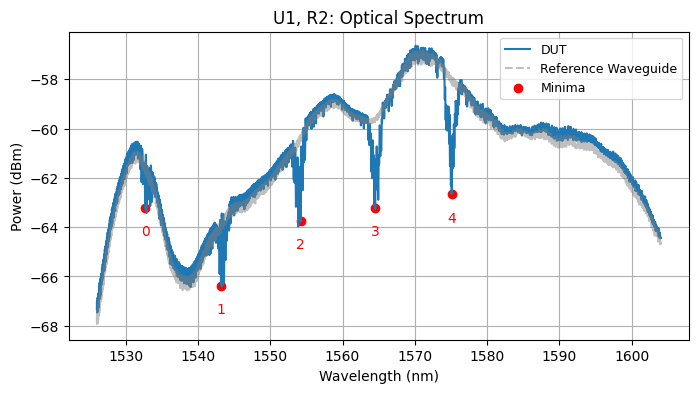

In [16]:
# Processing parameters
threshold_u1 = 1.5     # For minima detection (dB)

wl_u1_r2 = plot_spectra(wavelength_u1_r2, power_u1_r2, power_wg_r2, threshold_u1, separation, "U1, R2")
# wl_u1_r4 = plot_spectra(wavelength_u1_r4, power_u1_r4, power_wg_r4, threshold, separation, "U1, R4")
# wl_u1_r7 = plot_spectra(wavelength_u1_r7, power_u1_r7, power_wg_r7, threshold, separation, "U1, R7")
# wl_u1_r10 = plot_spectra(wavelength_u1_r10, power_u1_r10, power_wg_r10, threshold, separation, "U1, R10")
# wl_u1_r12 = plot_spectra(wavelength_u1_r12, power_u1_r12, power_wg_r12, threshold, separation, "U1, R12")

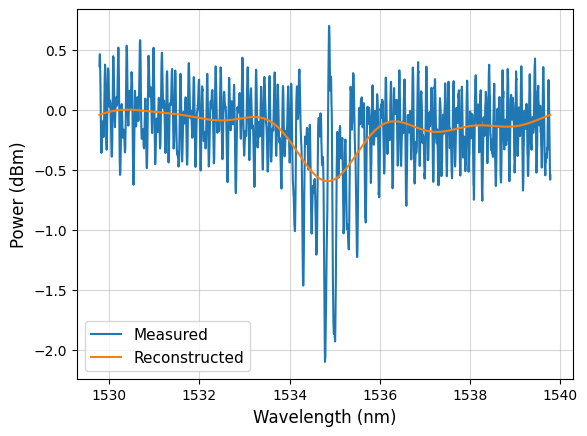

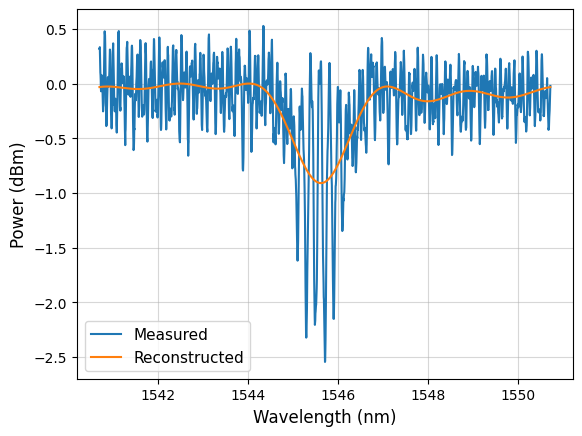

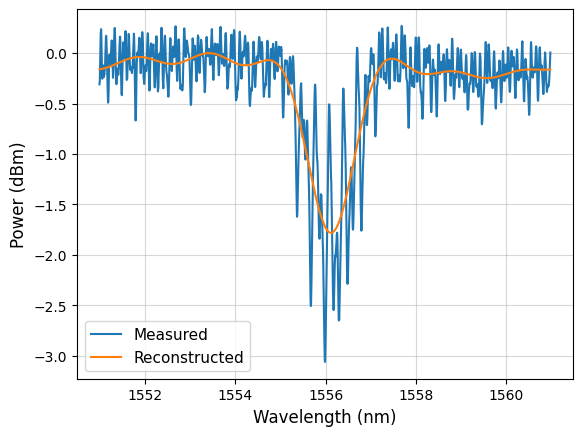

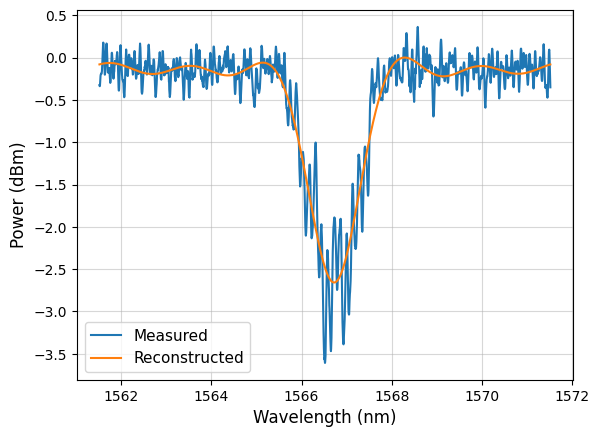

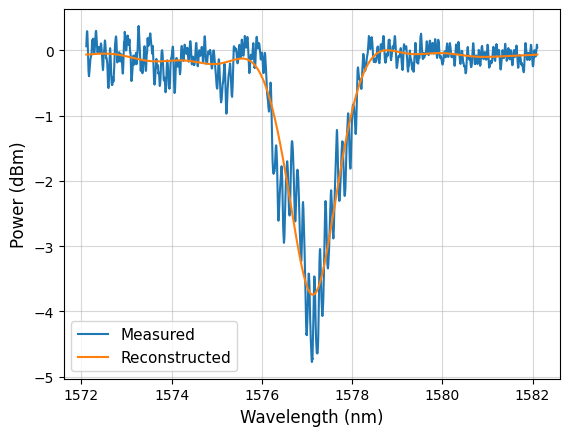

In [17]:
wavelength_dut = wavelength_u1_r10
power_dut = power_u1_r10
power_wg = power_wg_r10
fc = 0.6
idx_array = [0, 1, 2, 3, 4]

for idx in idx_array:
    fourier_test(idx, wavelength_dut, power_dut, power_wg, window_size_res, fc, threshold_u1, separation)

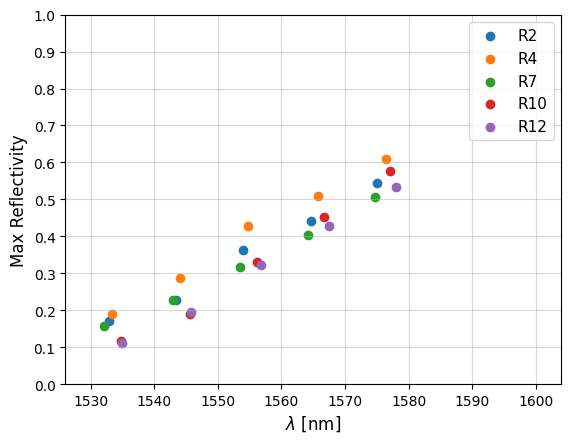

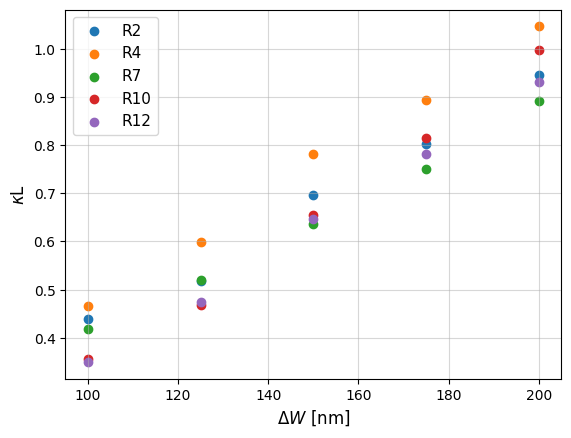

In [18]:
fc_u1 = 0.6
wl_u1_r2_fourier, R_u1_r2_fourier, BW_u1_r2_fourier = reflectivity(wavelength_u1_r2, power_u1_r2, power_wg_r2, window_size_res, fc_u1, threshold_u1, separation)
wl_u1_r4_fourier, R_u1_r4_fourier, BW_u1_r4_fourier = reflectivity(wavelength_u1_r4, power_u1_r4, power_wg_r4, window_size_res, fc_u1, threshold_u1, separation)
wl_u1_r7_fourier, R_u1_r7_fourier, BW_u1_r7_fourier = reflectivity(wavelength_u1_r7, power_u1_r7, power_wg_r7, window_size_res, fc_u1, threshold_u1, separation)
wl_u1_r10_fourier, R_u1_r10_fourier, BW_u1_r10_fourier = reflectivity(wavelength_u1_r10, power_u1_r10, power_wg_r10, window_size_res, fc_u1, threshold_u1, separation)
wl_u1_r12_fourier, R_u1_r12_fourier, BW_u1_r12_fourier = reflectivity(wavelength_u1_r12, power_u1_r12, power_wg_r12, window_size_res, fc_u1, threshold_u1, separation)

plt.scatter(wl_u1_r2_fourier, R_u1_r2_fourier, label='R2')
plt.scatter(wl_u1_r4_fourier, R_u1_r4_fourier, label='R4')
plt.scatter(wl_u1_r7_fourier, R_u1_r7_fourier, label='R7')
plt.scatter(wl_u1_r10_fourier, R_u1_r10_fourier, label='R10')
plt.scatter(wl_u1_r12_fourier, R_u1_r12_fourier, label='R12')

plt.xlabel(r"$\lambda$ [nm]", fontsize=12)
#plt.title("Reflectivity of U1")
plt.ylabel('Max Reflectivity', fontsize=12)
plt.ylim(0, 1)
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.xlim(wl_0, wl_1)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11)
#plt.savefig("U1_reflectivity.png", dpi=300, bbox_inches="tight")
plt.show()

plt.scatter((width[4:] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u1_r2_fourier)), label='R2')
plt.scatter((width[4:] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u1_r4_fourier)), label='R4')
plt.scatter((width[4:] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u1_r7_fourier)), label='R7')
plt.scatter((width[4:] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u1_r10_fourier)), label='R10')
plt.scatter((width[4:] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u1_r12_fourier)), label='R12')

plt.xlabel(r"$\Delta W$ [nm]", fontsize=12)
#plt.title(r"$\kappa$L")
plt.ylabel(r"$\kappa$L", fontsize=12)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11)
#plt.savefig("U1_kappaL.png", dpi=300, bbox_inches="tight")
plt.show()

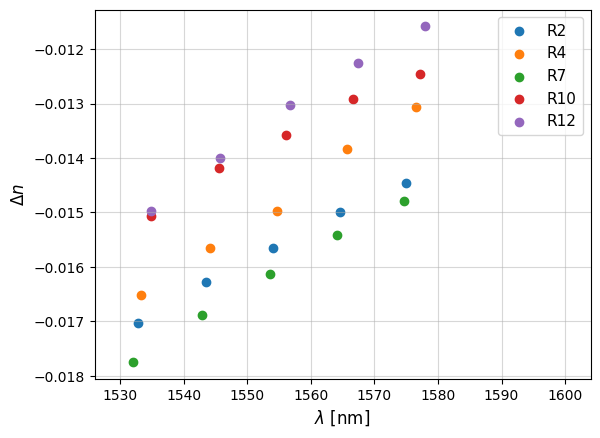

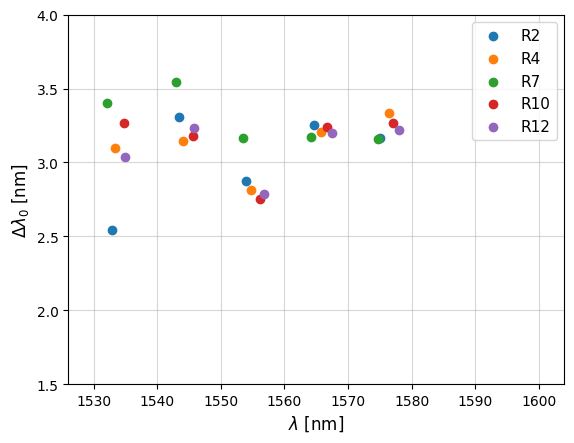

In [19]:
period_array =  np.array(period_array_u1)*1e-6

dwl_u1_r2_fourier, dn_u1_r2_fourier = shift_analysis(wl_u1, wl_u1_r2_fourier, period_array)
dwl_u1_r4_fourier, dn_u1_r4_fourier = shift_analysis(wl_u1, wl_u1_r4_fourier, period_array)
dwl_u1_r7_fourier, dn_u1_r7_fourier = shift_analysis(wl_u1, wl_u1_r7_fourier, period_array)
dwl_u1_r10_fourier, dn_u1_r10_fourier = shift_analysis(wl_u1, wl_u1_r10_fourier, period_array)
dwl_u1_r12_fourier, dn_u1_r12_fourier = shift_analysis(wl_u1, wl_u1_r12_fourier, period_array)

plt.scatter(wl_u1_r2_fourier, dn_u1_r2_fourier, label='R2')
plt.scatter(wl_u1_r4_fourier, dn_u1_r4_fourier, label='R4')
plt.scatter(wl_u1_r7_fourier, dn_u1_r7_fourier, label='R7')
plt.scatter(wl_u1_r10_fourier, dn_u1_r10_fourier, label='R10')
plt.scatter(wl_u1_r12_fourier, dn_u1_r12_fourier, label='R12')

plt.xlabel(r"$\lambda$ [nm]", fontsize=12)
plt.ylabel(r"$\Delta n$", fontsize=12)
#plt.title("Refractive Index Shift of U1")
plt.xlim(wl_0, wl_1)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11) 
# plt.savefig("U1_index_shift.png", dpi=300, bbox_inches="tight")  
plt.show()

plt.scatter(wl_u1_r2_fourier, BW_u1_r2_fourier, label='R2')
plt.scatter(wl_u1_r4_fourier, BW_u1_r4_fourier, label='R4')
plt.scatter(wl_u1_r7_fourier, BW_u1_r7_fourier, label='R7')
plt.scatter(wl_u1_r10_fourier, BW_u1_r10_fourier, label='R10')
plt.scatter(wl_u1_r12_fourier, BW_u1_r12_fourier, label='R12')

plt.xlabel(r"$\lambda$ [nm]", fontsize=12)
plt.ylabel(r"$\Delta \lambda_0$ [nm]", fontsize=12)
#plt.title("Bandwidth of U1")
plt.xlim(wl_0, wl_1)
plt.ylim(1.5, 4)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11) 
#plt.savefig("U1_bandwidth.png", dpi=300, bbox_inches="tight")  
plt.show()

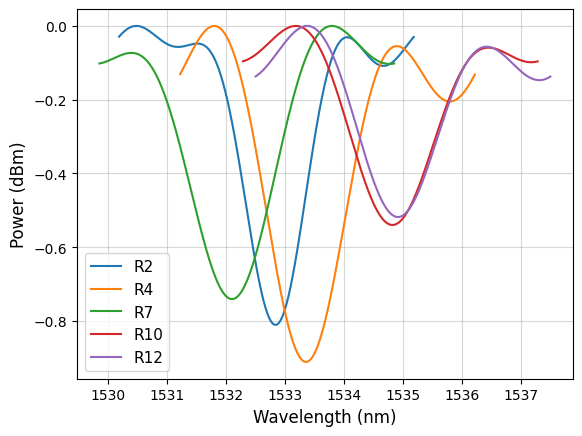

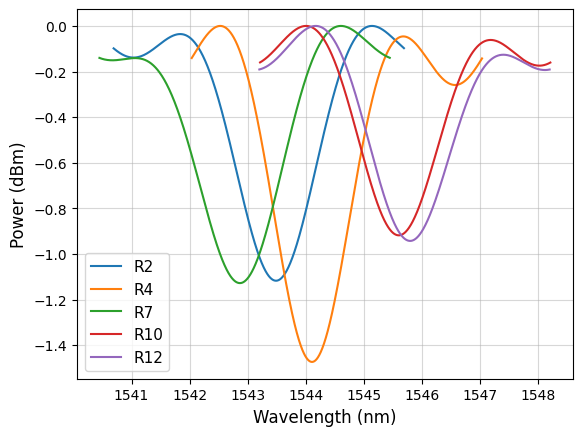

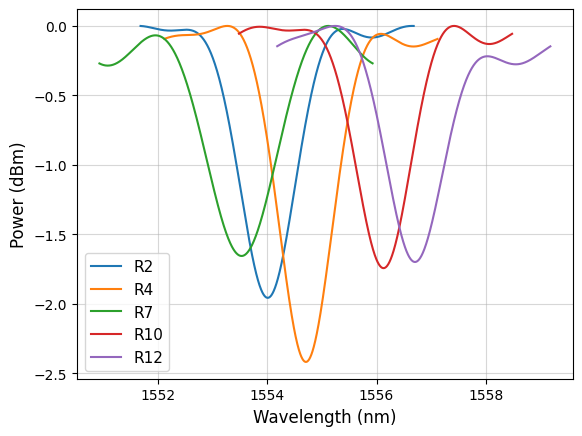

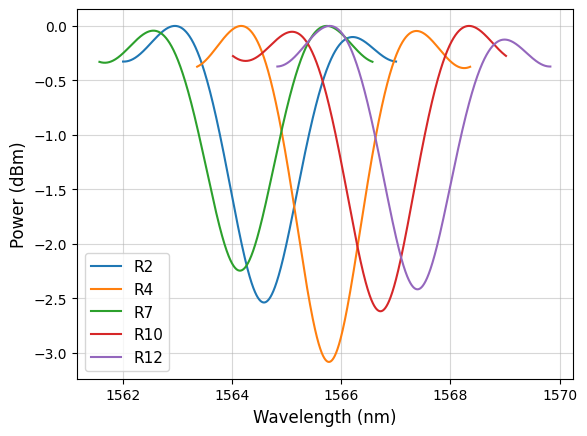

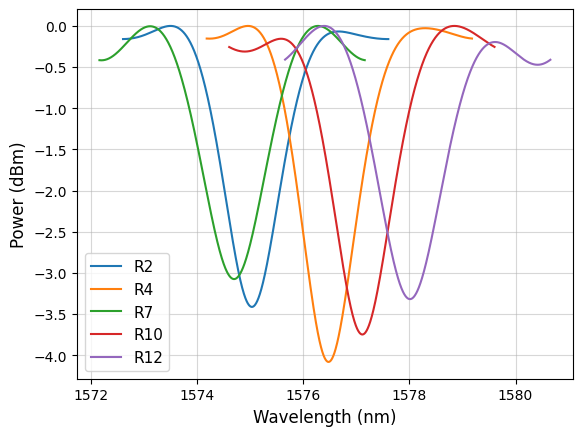

In [20]:
reticles = ['R2', 'R4', 'R7', 'R10', 'R12']

for idx in range(len(dw_measure_u1)):
    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u1_r2, power_u1_r2, power_wg_r2, window_size_res, fc_u1, threshold_u1, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R2')

    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u1_r4, power_u1_r4, power_wg_r4, window_size_res, fc_u1, threshold_u1, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R4')

    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u1_r7, power_u1_r7, power_wg_r7, window_size_res, fc_u1, threshold_u1, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R7')

    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u1_r10, power_u1_r10, power_wg_r10, window_size_res, fc_u1, threshold_u1, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R10')

    
    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u1_r12, power_u1_r12, power_wg_r12, window_size_res, fc_u1, threshold_u1, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R12')

    plt.xlabel("Wavelength (nm)", fontsize=12)
    plt.ylabel("Power (dBm)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(which='both', alpha=0.5)
    plt.show()

In [21]:
L_u1 = (np.array(period_array_u1)*N_u1*1e-6)[3:]

wls_u1 = [wl_u1_r2_fourier, wl_u1_r4_fourier, wl_u1_r7_fourier, wl_u1_r10_fourier, wl_u1_r12_fourier]
wls_mean_u1 = np.mean(wls_u1, axis=0)
for i in range(len(wls_u1[0])):
    print(rf'${np.round(np.mean(wls_u1, axis=0)[i],1)} \pm {np.round(np.std(wls_u1, axis=0)[i], 1)}$')

print('\n')
bws_u1 = [BW_u1_r2_fourier, BW_u1_r4_fourier, BW_u1_r7_fourier, BW_u1_r10_fourier, BW_u1_r12_fourier]
bws_mean_u1 = np.mean(bws_u1, axis=0)
for j in range(len(bws_u1[0])):
    print(rf'${np.round(np.mean(bws_u1, axis=0)[j],2)} \pm {np.round(np.std(bws_u1, axis=0)[j], 2)}$')

print('\n')
ks_u1 = [np.arctanh(np.sqrt(R_u1_r2_fourier))/L_u1, np.arctanh(np.sqrt(R_u1_r4_fourier))/L_u1, np.arctanh(np.sqrt(R_u1_r7_fourier))/L_u1, 
       np.arctanh(np.sqrt(R_u1_r10_fourier))/L_u1, np.arctanh(np.sqrt(R_u1_r12_fourier))/L_u1]
ks_mean_u1 = np.mean(ks_u1, axis=0)
for k in range(len(ks_u1[0])):
    print(rf'${np.round(np.mean(ks_u1, axis=0)[k]*1e-3,2)} \pm {np.round(np.std(ks_u1, axis=0)[k]*1e-3, 2)}$')

print('\n')
kls_u1 = [np.arctanh(np.sqrt(R_u1_r2_fourier)), np.arctanh(np.sqrt(R_u1_r4_fourier)), np.arctanh(np.sqrt(R_u1_r7_fourier)), 
       np.arctanh(np.sqrt(R_u1_r10_fourier)), np.arctanh(np.sqrt(R_u1_r12_fourier))]
kls_mean_u1 = np.mean(kls_u1, axis=0)
for k in range(len(kls_u1[0])):
    print(rf'${np.round(np.mean(kls_u1, axis=0)[k],2)} \pm {np.round(np.std(kls_u1, axis=0)[k], 2)}$')

print('\n')
tmins_u1 = [10*np.log10(1-R_u1_r2_fourier), 10*np.log10(1-R_u1_r4_fourier), 10*np.log10(1-R_u1_r7_fourier), 
        10*np.log10(1-R_u1_r10_fourier), 10*np.log10(1-R_u1_r12_fourier)]
tmins_mean_u1 = np.mean(tmins_u1, axis=0)
for l in range(len(tmins_u1[0])):
    print(rf'${np.round(np.mean(tmins_u1, axis=0)[l],2)} \pm {np.round(np.std(tmins_u1, axis=0)[l], 2)}$')

$1533.6 \pm 1.1$
$1544.4 \pm 1.2$
$1555.0 \pm 1.2$
$1565.7 \pm 1.2$
$1576.3 \pm 1.2$


$3.07 \pm 0.29$
$3.28 \pm 0.14$
$2.88 \pm 0.15$
$3.21 \pm 0.03$
$3.23 \pm 0.07$


$0.8 \pm 0.09$
$1.02 \pm 0.09$
$1.34 \pm 0.1$
$1.57 \pm 0.09$
$1.86 \pm 0.1$


$0.41 \pm 0.05$
$0.52 \pm 0.05$
$0.68 \pm 0.05$
$0.81 \pm 0.05$
$0.96 \pm 0.05$


$-0.7 \pm 0.15$
$-1.12 \pm 0.2$
$-1.89 \pm 0.28$
$-2.58 \pm 0.28$
$-3.53 \pm 0.35$


## U2

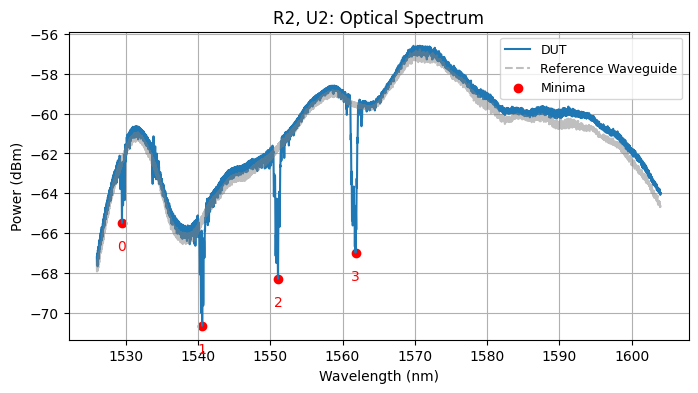

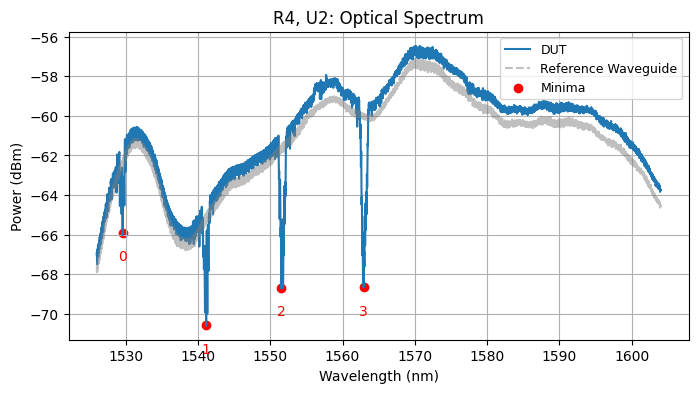

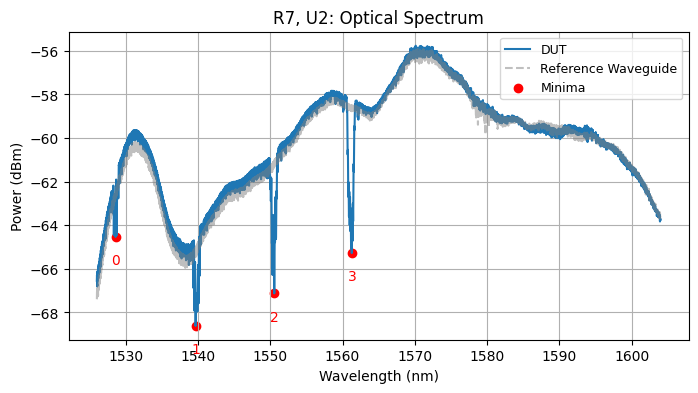

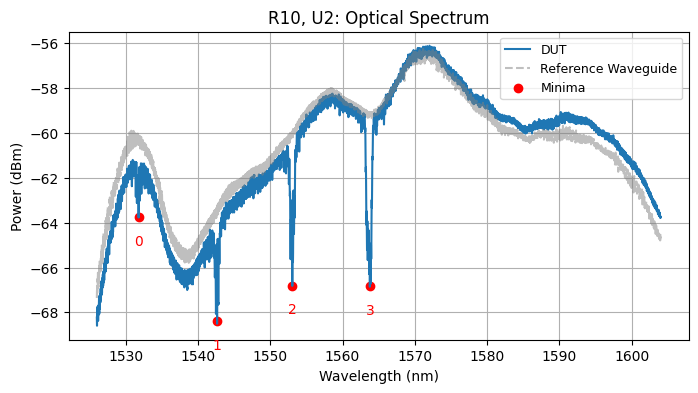

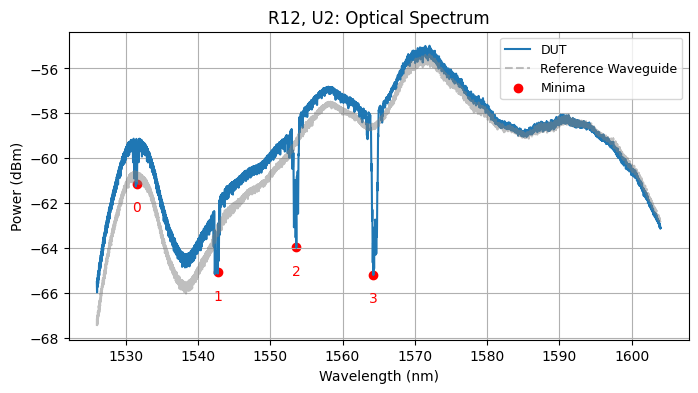

In [22]:
# Processing parameters
threshold_u2 = 2.0       # For minima detection (dB)

wl_u2_r2 = plot_spectra(wavelength_u2_r2, power_u2_r2, power_wg_r2, threshold_u2, separation, "R2, U2")
wl_u2_r4 = plot_spectra(wavelength_u2_r4, power_u2_r4, power_wg_r4, threshold_u2, separation, "R4, U2")
wl_u2_r7 = plot_spectra(wavelength_u2_r7, power_u2_r7, power_wg_r7, threshold_u2, separation, "R7, U2")
wl_u2_r10 = plot_spectra(wavelength_u2_r10, power_u2_r10, power_wg_r10, threshold_u2, separation, "R10, U2")
wl_u2_r12 = plot_spectra(wavelength_u2_r12, power_u2_r12, power_wg_r12, threshold_u2, separation, "R12, U2")

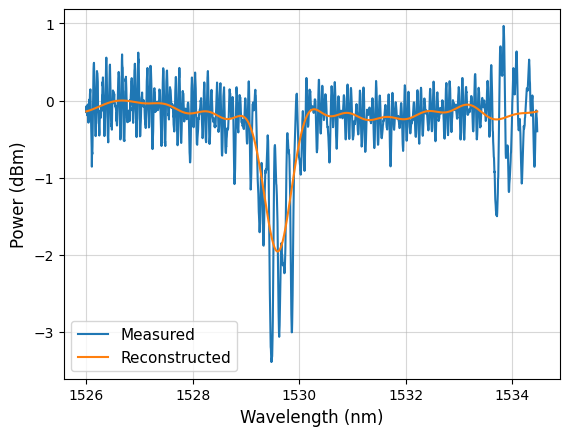

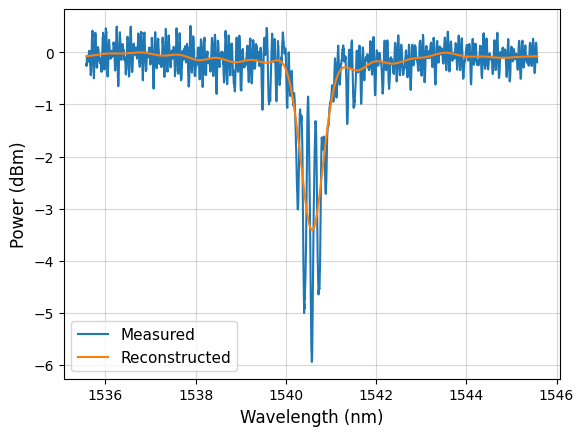

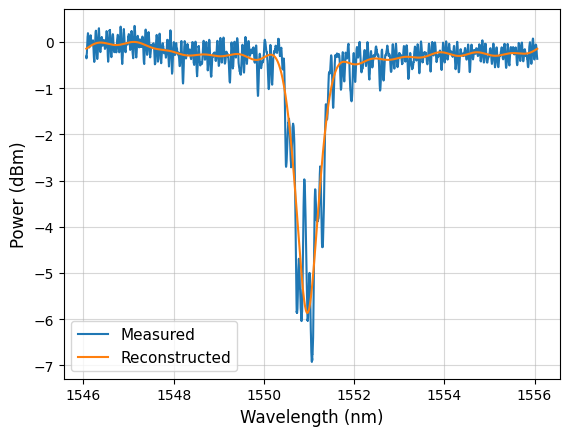

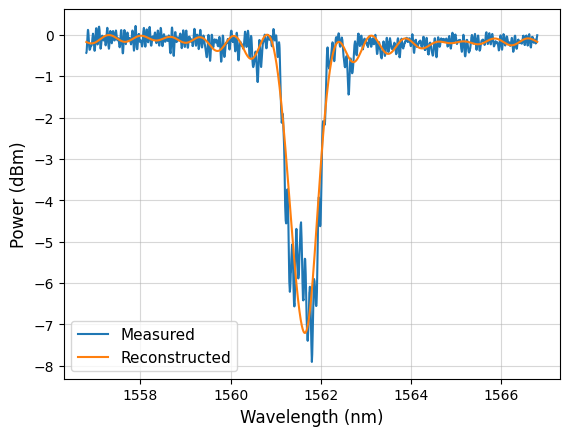

In [23]:
wavelength_dut = wavelength_u2_r2
power_dut = power_u2_r2
power_wg = power_wg_r2
fc = 1.4
idx_array = [0, 1, 2, 3]

for idx in idx_array:
    fourier_test(idx, wavelength_dut, power_dut, power_wg, window_size_res, fc, threshold_u2, separation)

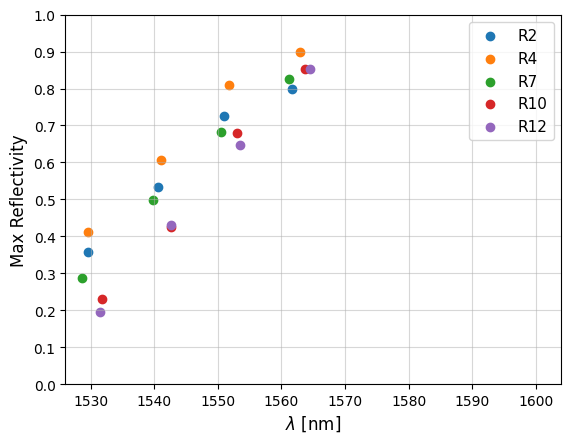

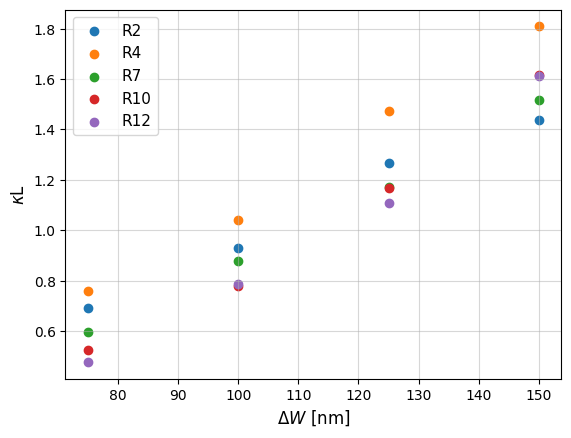

In [24]:
fc_u2 = 1.4
wl_u2_r2_fourier, R_u2_r2_fourier, BW_u2_r2_fourier = reflectivity(wavelength_u2_r2, power_u2_r2, power_wg_r2, window_size_res, fc_u2, threshold_u2, separation)
wl_u2_r4_fourier, R_u2_r4_fourier, BW_u2_r4_fourier = reflectivity(wavelength_u2_r4, power_u2_r4, power_wg_r4, window_size_res, fc_u2, threshold_u2, separation)
wl_u2_r7_fourier, R_u2_r7_fourier, BW_u2_r7_fourier = reflectivity(wavelength_u2_r7, power_u2_r7, power_wg_r7, window_size_res, fc_u2, threshold_u2, separation)
wl_u2_r10_fourier, R_u2_r10_fourier, BW_u2_r10_fourier = reflectivity(wavelength_u2_r10, power_u2_r10, power_wg_r10, window_size_res, fc_u2, threshold_u2, separation)
wl_u2_r12_fourier, R_u2_r12_fourier, BW_u2_r12_fourier = reflectivity(wavelength_u2_r12, power_u2_r12, power_wg_r12, window_size_res, fc_u2, threshold_u2, separation)

plt.scatter(wl_u2_r2_fourier, R_u2_r2_fourier, label='R2')
plt.scatter(wl_u2_r4_fourier, R_u2_r4_fourier, label='R4')
plt.scatter(wl_u2_r7_fourier, R_u2_r7_fourier, label='R7')
plt.scatter(wl_u2_r10_fourier, R_u2_r10_fourier, label='R10')
plt.scatter(wl_u2_r12_fourier, R_u2_r12_fourier, label='R12')

plt.xlabel(r"$\lambda$ [nm]", fontsize=12)
#plt.title("Reflectivity of U2")
plt.ylabel('Max Reflectivity', fontsize=12)
plt.ylim(0, 1)
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.xlim(wl_0, wl_1)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11)
#plt.savefig("U2_reflectivity.png", dpi=300, bbox_inches="tight")
plt.show()

plt.scatter((width[3:7] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u2_r2_fourier)), label='R2')
plt.scatter((width[3:7] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u2_r4_fourier)), label='R4')
plt.scatter((width[3:7] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u2_r7_fourier)), label='R7')
plt.scatter((width[3:7] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u2_r10_fourier)), label='R10')
plt.scatter((width[3:7] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u2_r12_fourier)), label='R12')

plt.xlabel(r"$\Delta W$ [nm]", fontsize=12)
#plt.title(r"$\kappa$L")
plt.ylabel(r"$\kappa$L", fontsize=12)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11)
#plt.savefig("U2_kappaL.png", dpi=300, bbox_inches="tight")
plt.show()

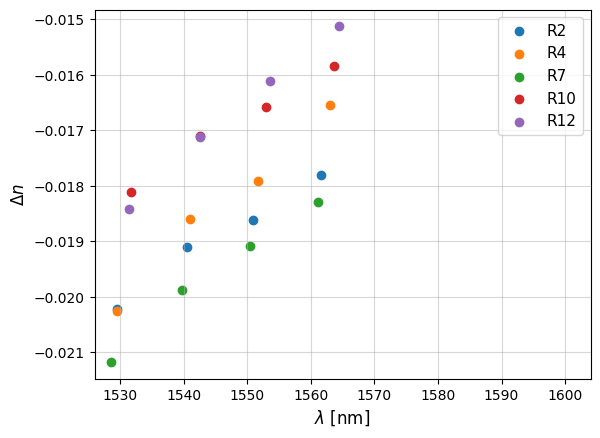

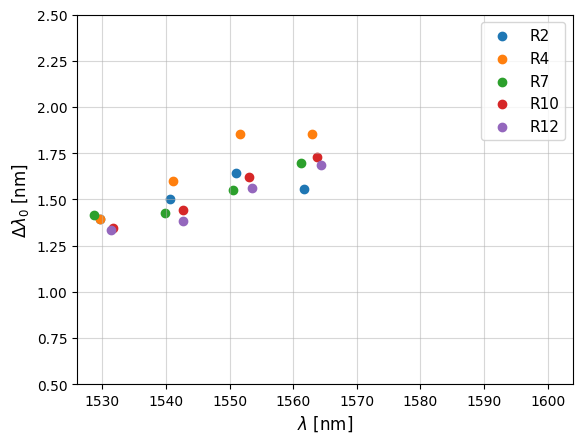

In [25]:
period_array =  np.array(period_array_u2)*1e-6

dwl_u2_r2_fourier, dn_u2_r2_fourier = shift_analysis(wl_u2, wl_u2_r2_fourier, period_array)
dwl_u2_r4_fourier, dn_u2_r4_fourier = shift_analysis(wl_u2, wl_u2_r4_fourier, period_array)
dwl_u2_r7_fourier, dn_u2_r7_fourier = shift_analysis(wl_u2, wl_u2_r7_fourier, period_array)
dwl_u2_r10_fourier, dn_u2_r10_fourier = shift_analysis(wl_u2, wl_u2_r10_fourier, period_array)
dwl_u2_r12_fourier, dn_u2_r12_fourier = shift_analysis(wl_u2, wl_u2_r12_fourier, period_array)

plt.scatter(wl_u2_r2_fourier, dn_u2_r2_fourier, label='R2')
plt.scatter(wl_u2_r4_fourier, dn_u2_r4_fourier, label='R4')
plt.scatter(wl_u2_r7_fourier, dn_u2_r7_fourier, label='R7')
plt.scatter(wl_u2_r10_fourier, dn_u2_r10_fourier, label='R10')
plt.scatter(wl_u2_r12_fourier, dn_u2_r12_fourier, label='R12')

plt.xlabel(r"$\lambda$ [nm]", fontsize=12)
plt.ylabel(r"$\Delta n$", fontsize=12)
#plt.title("Refractive Index Shift of U2")
plt.xlim(wl_0, wl_1)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11) 
#plt.savefig("U2_index_shift.png", dpi=300, bbox_inches="tight")  
plt.show()

plt.scatter(wl_u2_r2_fourier, BW_u2_r2_fourier, label='R2')
plt.scatter(wl_u2_r4_fourier, BW_u2_r4_fourier, label='R4')
plt.scatter(wl_u2_r7_fourier, BW_u2_r7_fourier, label='R7')
plt.scatter(wl_u2_r10_fourier, BW_u2_r10_fourier, label='R10')
plt.scatter(wl_u2_r12_fourier, BW_u2_r12_fourier, label='R12')

plt.xlabel(r"$\lambda$ [nm]", fontsize=12)
plt.ylabel(r"$\Delta \lambda_0$ [nm]", fontsize=12)
#plt.title("Bandwidth of U2")
plt.xlim(wl_0, wl_1)
plt.ylim(0.5, 2.5)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11) 
#plt.savefig("U2_bandwidth.png", dpi=300, bbox_inches="tight")  
plt.show()

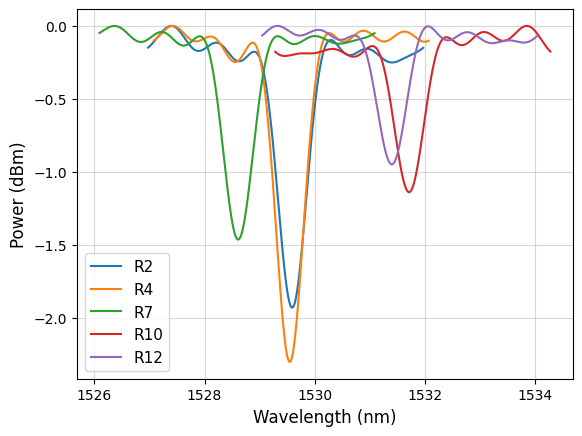

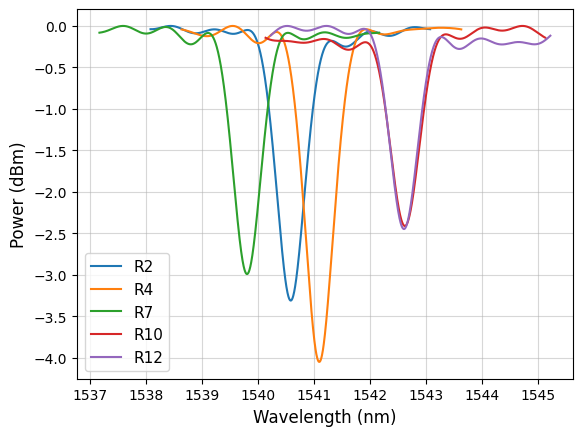

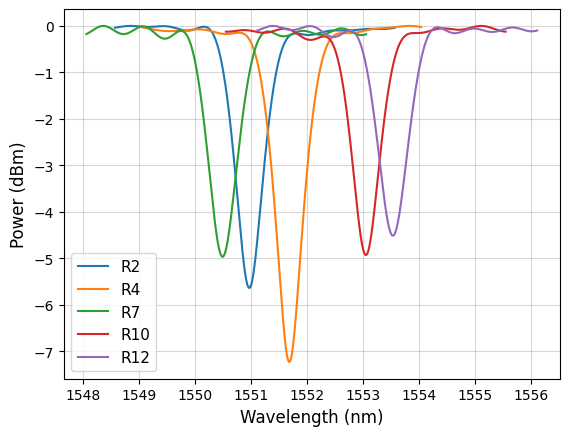

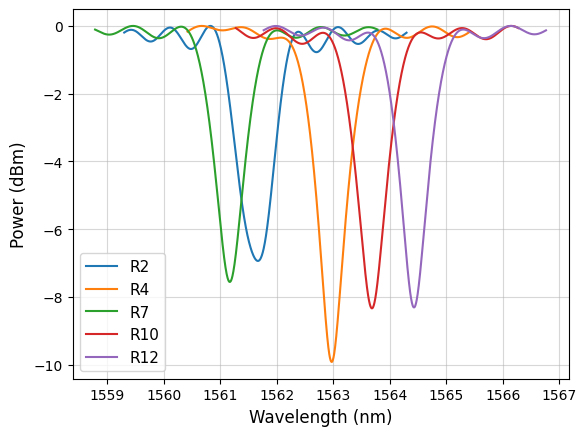

In [26]:
reticles = ['R2', 'R4', 'R7', 'R10', 'R12']

for idx in range(len(dw_measure_u2)):
    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u2_r2, power_u2_r2, power_wg_r2, window_size_res, fc_u2, threshold_u2, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R2')

    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u2_r4, power_u2_r4, power_wg_r4, window_size_res, fc_u2, threshold_u2, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R4')

    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u2_r7, power_u2_r7, power_wg_r7, window_size_res, fc_u2, threshold_u2, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R7')

    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u2_r10, power_u2_r10, power_wg_r10, window_size_res, fc_u2, threshold_u2, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R10')

    
    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u2_r12, power_u2_r12, power_wg_r12, window_size_res, fc_u2, threshold_u2, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R12')

    plt.xlabel("Wavelength (nm)", fontsize=12)
    plt.ylabel("Power (dBm)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(which='both', alpha=0.5)
    plt.show()

In [27]:
L_u2 = (np.array(period_array_u2)*N_u2*1e-6)[2:]

wls_u2 = [wl_u2_r2_fourier, wl_u2_r4_fourier, wl_u2_r7_fourier, wl_u2_r10_fourier, wl_u2_r12_fourier]
wls_mean_u2 = np.mean(wls_u2, axis=0)
for i in range(len(wls_u2[0])):
    print(rf'${np.round(np.mean(wls_u2, axis=0)[i],1)} \pm {np.round(np.std(wls_u2, axis=0)[i], 1)}$')

print('\n')
bws_u2 = [BW_u2_r2_fourier, BW_u2_r4_fourier, BW_u2_r7_fourier, BW_u2_r10_fourier, BW_u2_r12_fourier]
bws_mean_u2 = np.mean(bws_u2, axis=0)
for j in range(len(bws_u2[0])):
    print(rf'${np.round(np.mean(bws_u2, axis=0)[j],2)} \pm {np.round(np.std(bws_u2, axis=0)[j], 2)}$')

print('\n')
ks_u2 = [np.arctanh(np.sqrt(R_u2_r2_fourier))/L_u2, np.arctanh(np.sqrt(R_u2_r4_fourier))/L_u2, np.arctanh(np.sqrt(R_u2_r7_fourier))/L_u2, 
       np.arctanh(np.sqrt(R_u2_r10_fourier))/L_u2, np.arctanh(np.sqrt(R_u2_r12_fourier))/L_u2]
ks_mean_u2 = np.mean(ks_u2, axis=0)
for k in range(len(ks_u2[0])):
    print(rf'${np.round(np.mean(ks_u2, axis=0)[k]*1e-3,2)} \pm {np.round(np.std(ks_u2, axis=0)[k]*1e-3, 2)}$')

print('\n')
kls_u2 = [np.arctanh(np.sqrt(R_u2_r2_fourier)), np.arctanh(np.sqrt(R_u2_r4_fourier)), np.arctanh(np.sqrt(R_u2_r7_fourier)), 
       np.arctanh(np.sqrt(R_u2_r10_fourier)), np.arctanh(np.sqrt(R_u2_r12_fourier))]
kls_mean_u2 = np.mean(kls_u2, axis=0)
for k in range(len(kls_u2[0])):
    print(rf'${np.round(np.mean(kls_u2, axis=0)[k],2)} \pm {np.round(np.std(kls_u2, axis=0)[k], 2)}$')

print('\n')
tmins_u2 = [10*np.log10(1-R_u2_r2_fourier), 10*np.log10(1-R_u2_r4_fourier), 10*np.log10(1-R_u2_r7_fourier), 
        10*np.log10(1-R_u2_r10_fourier), 10*np.log10(1-R_u2_r12_fourier)]
tmins_mean_u2 = np.mean(tmins_u2, axis=0)
for l in range(len(tmins_u2[0])):
    print(rf'${np.round(np.mean(tmins_u2, axis=0)[l],2)} \pm {np.round(np.std(tmins_u2, axis=0)[l], 2)}$')

$1530.2 \pm 1.2$
$1541.3 \pm 1.1$
$1551.9 \pm 1.2$
$1562.8 \pm 1.2$


$1.38 \pm 0.03$
$1.47 \pm 0.07$
$1.65 \pm 0.11$
$1.7 \pm 0.09$


$0.6 \pm 0.1$
$0.87 \pm 0.1$
$1.21 \pm 0.13$
$1.55 \pm 0.12$


$0.61 \pm 0.1$
$0.88 \pm 0.1$
$1.24 \pm 0.13$
$1.6 \pm 0.12$


$-1.56 \pm 0.5$
$-3.04 \pm 0.61$
$-5.45 \pm 0.96$
$-8.21 \pm 1.0$


## U3

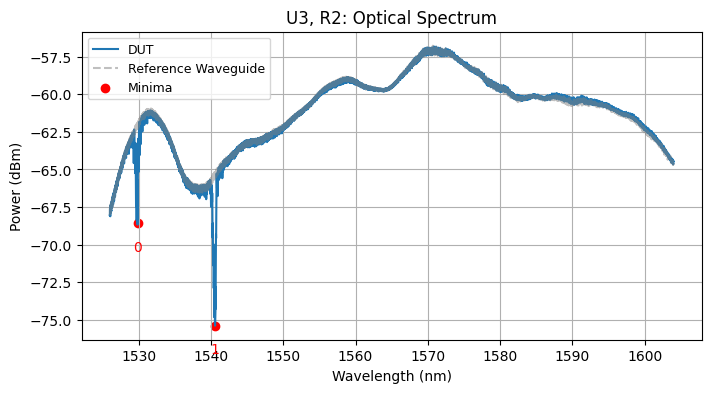

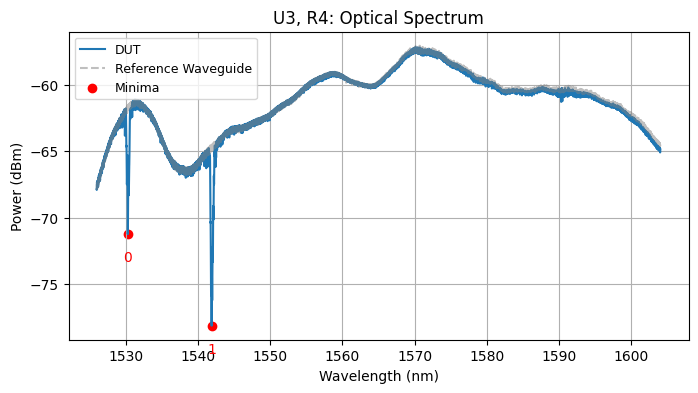

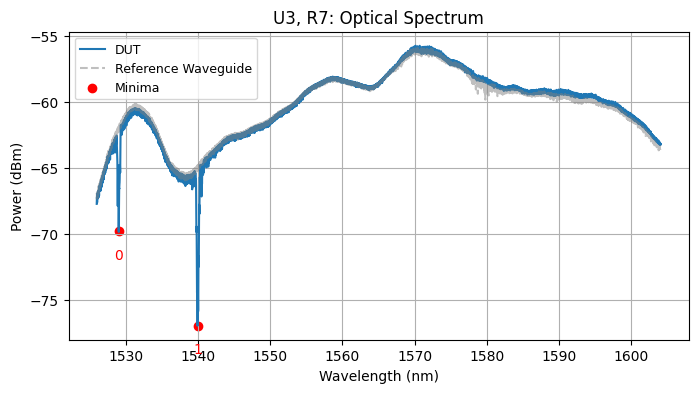

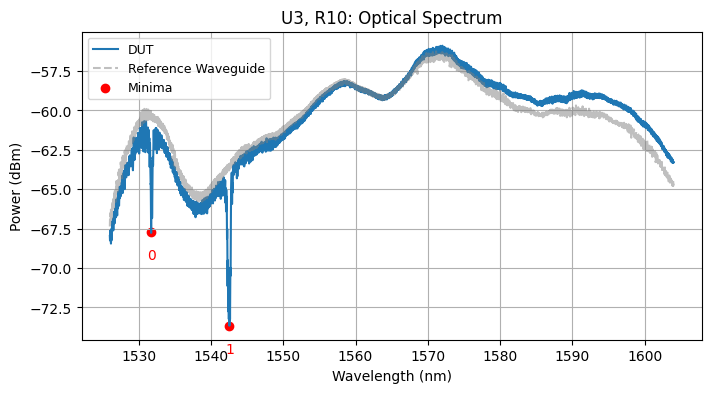

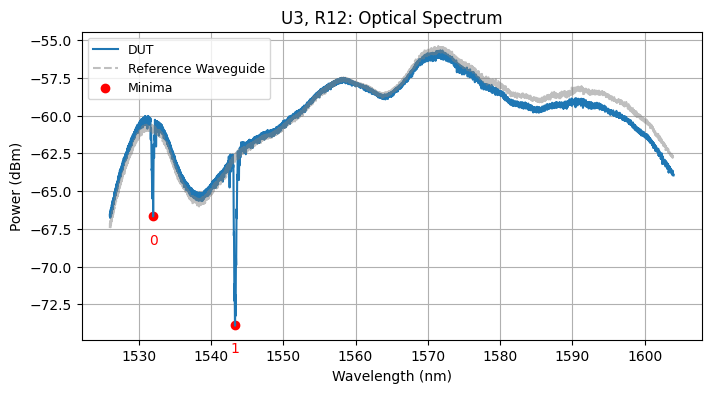

In [28]:
# Processing parameters
threshold_u3 = 2.0       # For minima detection (dB)

wl_u3_r2 = plot_spectra(wavelength_u3_r2, power_u3_r2, power_wg_r2, threshold_u3, separation, "U3, R2")
wl_u3_r4 = plot_spectra(wavelength_u3_r4, power_u3_r4, power_wg_r4, threshold_u3, separation, "U3, R4")
wl_u3_r7 = plot_spectra(wavelength_u3_r7, power_u3_r7, power_wg_r7, threshold_u3, separation, "U3, R7")
wl_u3_r10 = plot_spectra(wavelength_u3_r10, power_u3_r10, power_wg_r10, threshold_u3, separation, "U3, R10")
wl_u3_r12 = plot_spectra(wavelength_u3_r12, power_u3_r12, power_wg_r12, threshold_u3, separation, "U3, R12")

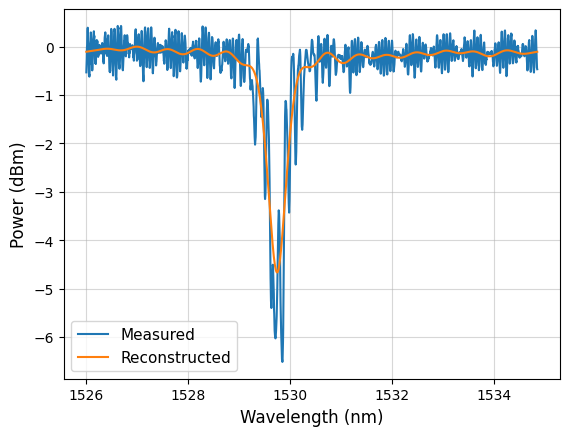

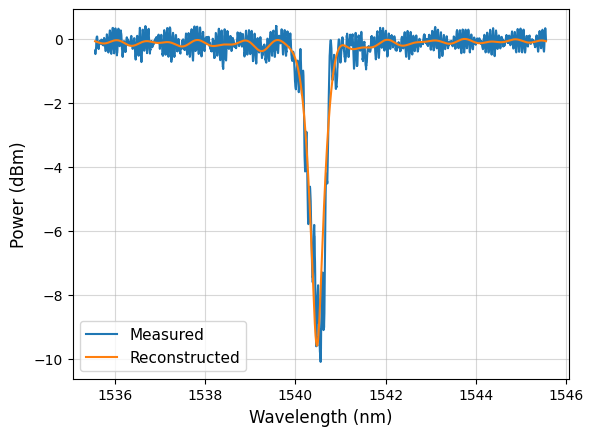

In [29]:
wavelength_dut = wavelength_u3_r2
power_dut = power_u3_r2
power_wg = power_wg_r2
fc = 1.7
idx_array = [0, 1]

for idx in idx_array:
    fourier_test(idx, wavelength_dut, power_dut, power_wg, window_size_res, fc, threshold_u3, separation)

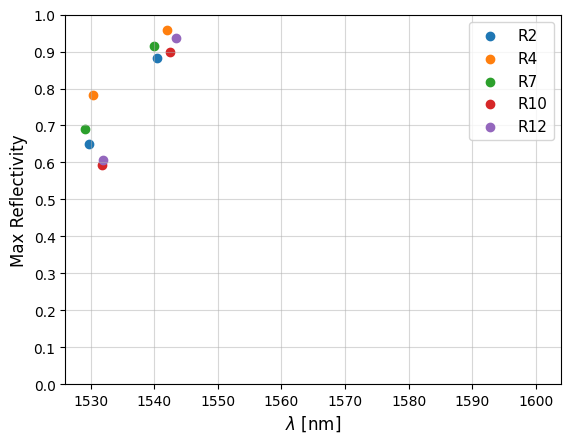

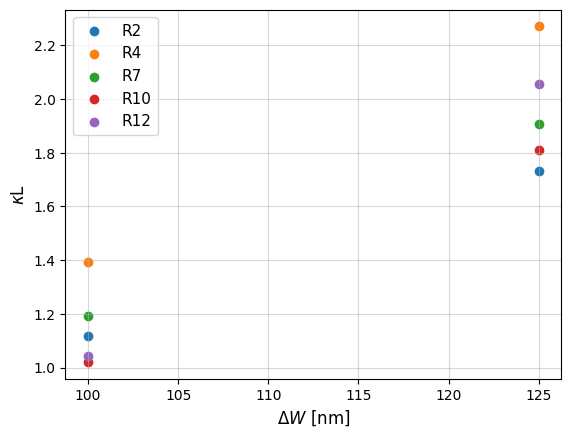

In [30]:
fc_u3 = 1.7
wl_u3_r2_fourier, R_u3_r2_fourier, BW_u3_r2_fourier = reflectivity(wavelength_u3_r2, power_u3_r2, power_wg_r2, window_size_res, fc_u3, threshold_u3, separation)
wl_u3_r4_fourier, R_u3_r4_fourier, BW_u3_r4_fourier = reflectivity(wavelength_u3_r4, power_u3_r4, power_wg_r4, window_size_res, fc_u3, threshold_u3, separation)
wl_u3_r7_fourier, R_u3_r7_fourier, BW_u3_r7_fourier = reflectivity(wavelength_u3_r7, power_u3_r7, power_wg_r7, window_size_res, fc_u3, threshold_u3, separation)
wl_u3_r10_fourier, R_u3_r10_fourier, BW_u3_r10_fourier = reflectivity(wavelength_u3_r10, power_u3_r10, power_wg_r10, window_size_res, fc_u3, threshold_u3, separation)
wl_u3_r12_fourier, R_u3_r12_fourier, BW_u3_r12_fourier = reflectivity(wavelength_u3_r12, power_u3_r12, power_wg_r12, window_size_res, fc_u3, threshold_u3, separation)

plt.scatter(wl_u3_r2_fourier, R_u3_r2_fourier, label='R2')
plt.scatter(wl_u3_r4_fourier, R_u3_r4_fourier, label='R4')
plt.scatter(wl_u3_r7_fourier, R_u3_r7_fourier, label='R7')
plt.scatter(wl_u3_r10_fourier, R_u3_r10_fourier, label='R10')
plt.scatter(wl_u3_r12_fourier, R_u3_r12_fourier, label='R12')

plt.xlabel(r"$\lambda$ [nm]", fontsize=12)
#plt.title("Reflectivity of U3")
plt.ylabel('Max Reflectivity', fontsize=12)
plt.ylim(0, 1)
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.xlim(wl_0, wl_1)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11)
#plt.savefig("U3_reflectivity.png", dpi=300, bbox_inches="tight")
plt.show()

plt.scatter((width[4:6] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u3_r2_fourier)), label='R2')
plt.scatter((width[4:6] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u3_r4_fourier)), label='R4')
plt.scatter((width[4:6] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u3_r7_fourier)), label='R7')
plt.scatter((width[4:6] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u3_r10_fourier)), label='R10')
plt.scatter((width[4:6] - width_0)/2*1e3, np.arctanh(np.sqrt(R_u3_r12_fourier)), label='R12')

plt.xlabel(r"$\Delta W$ [nm]", fontsize=12)
#plt.title(r"$\kappa$L")
plt.ylabel(r"$\kappa$L", fontsize=12)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11)
#plt.savefig("U3_kappaL.png", dpi=300, bbox_inches="tight")
plt.show()

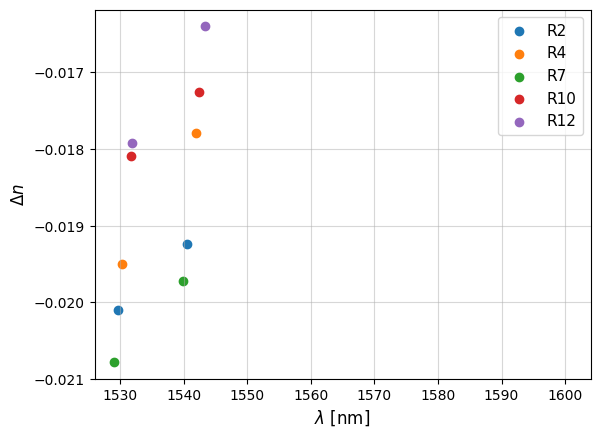

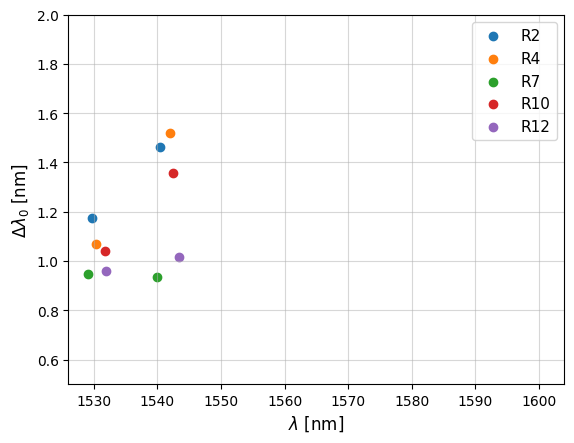

In [31]:
period_array =  np.array(period_array_u3)*1e-6

dwl_u3_r2_fourier, dn_u3_r2_fourier = shift_analysis(wl_u3, wl_u3_r2_fourier, period_array)
dwl_u3_r4_fourier, dn_u3_r4_fourier = shift_analysis(wl_u3, wl_u3_r4_fourier, period_array)
dwl_u3_r7_fourier, dn_u3_r7_fourier = shift_analysis(wl_u3, wl_u3_r7_fourier, period_array)
dwl_u3_r10_fourier, dn_u3_r10_fourier = shift_analysis(wl_u3, wl_u3_r10_fourier, period_array)
dwl_u3_r12_fourier, dn_u3_r12_fourier = shift_analysis(wl_u3, wl_u3_r12_fourier, period_array)

plt.scatter(wl_u3_r2_fourier, dn_u3_r2_fourier, label='R2')
plt.scatter(wl_u3_r4_fourier, dn_u3_r4_fourier, label='R4')
plt.scatter(wl_u3_r7_fourier, dn_u3_r7_fourier, label='R7')
plt.scatter(wl_u3_r10_fourier, dn_u3_r10_fourier, label='R10')
plt.scatter(wl_u3_r12_fourier, dn_u3_r12_fourier, label='R12')

plt.xlabel(r"$\lambda$ [nm]", fontsize=12)
plt.ylabel(r"$\Delta n$", fontsize=12)
#plt.title("Refractive Index Shift of U3")
plt.xlim(wl_0, wl_1)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11) 
#plt.savefig("U3_index_shift.png", dpi=300, bbox_inches="tight")  
plt.show()

plt.scatter(wl_u3_r2_fourier, BW_u3_r2_fourier, label='R2')
plt.scatter(wl_u3_r4_fourier, BW_u3_r4_fourier, label='R4')
plt.scatter(wl_u3_r7_fourier, BW_u3_r7_fourier, label='R7')
plt.scatter(wl_u3_r10_fourier, BW_u3_r10_fourier, label='R10')
plt.scatter(wl_u3_r12_fourier, BW_u3_r12_fourier, label='R12')

plt.xlabel(r"$\lambda$ [nm]", fontsize=12)
plt.ylabel(r"$\Delta \lambda_0$ [nm]", fontsize=12)
#plt.title("Bandwidth of U3")
plt.xlim(wl_0, wl_1)
plt.ylim(0.5, 2-0)
plt.grid(which='both', alpha=0.5)
plt.legend(fontsize=11) 
#plt.savefig("U3_bandwidth.png", dpi=300, bbox_inches="tight")  
plt.show()

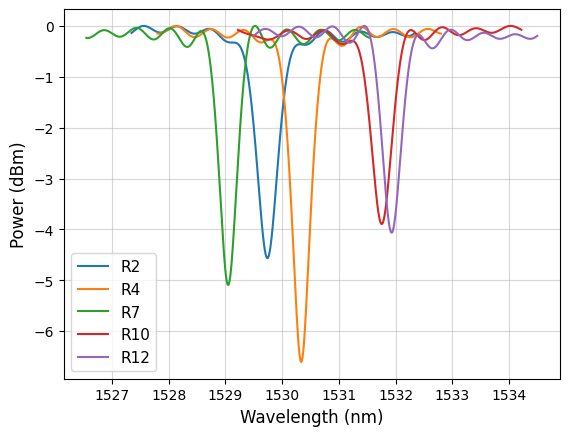

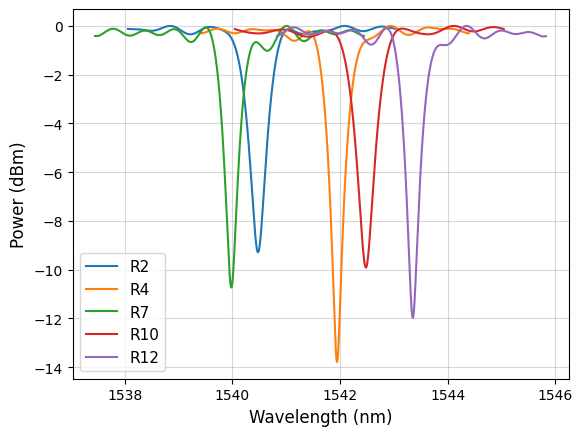

In [32]:
reticles = ['R2', 'R4', 'R7', 'R10', 'R12']

for idx in range(len(dw_measure_u3)):
    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u3_r2, power_u3_r2, power_wg_r2, window_size_res, fc_u3, threshold_u3, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R2')

    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u3_r4, power_u3_r4, power_wg_r4, window_size_res, fc_u3, threshold_u3, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R4')

    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u3_r7, power_u3_r7, power_wg_r7, window_size_res, fc_u3, threshold_u3, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R7')

    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u3_r10, power_u3_r10, power_wg_r10, window_size_res, fc_u3, threshold_u3, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R10')

    
    wavelength_zoom, power_zoom, power_zoom_ifft = get_resonance(idx, wavelength_u3_r12, power_u3_r12, power_wg_r12, window_size_res, fc_u3, threshold_u3, separation)
    plt.plot(wavelength_zoom, power_zoom_ifft, label=f'R12')

    plt.xlabel("Wavelength (nm)", fontsize=12)
    plt.ylabel("Power (dBm)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(which='both', alpha=0.5)
    plt.show()

In [33]:
L_u3 = (np.array(period_array_u3)*N_u3*1e-6)[2:]

wls_u3 = [wl_u3_r2_fourier, wl_u3_r4_fourier, wl_u3_r7_fourier, wl_u3_r10_fourier, wl_u3_r12_fourier]
wls_mean_u3 = np.mean(wls_u3, axis=0)
for i in range(len(wls_u3[0])):
    print(rf'${np.round(np.mean(wls_u3, axis=0)[i],1)} \pm {np.round(np.std(wls_u3, axis=0)[i], 1)}$')

print('\n')
bws_u3 = [BW_u3_r2_fourier, BW_u3_r4_fourier, BW_u3_r7_fourier, BW_u3_r10_fourier, BW_u3_r12_fourier]
bws_mean_u3 = np.mean(bws_u3, axis=0)
for j in range(len(bws_u3[0])):
    print(rf'${np.round(np.mean(bws_u3, axis=0)[j],2)} \pm {np.round(np.std(bws_u3, axis=0)[j], 2)}$')

print('\n')
ks_u3 = [np.arctanh(np.sqrt(R_u3_r2_fourier))/L_u3, np.arctanh(np.sqrt(R_u3_r4_fourier))/L_u3, np.arctanh(np.sqrt(R_u3_r7_fourier))/L_u3, 
       np.arctanh(np.sqrt(R_u3_r10_fourier))/L_u3, np.arctanh(np.sqrt(R_u3_r12_fourier))/L_u3]
ks_mean_u3 = np.mean(ks_u3, axis=0)
for k in range(len(ks_u3[0])):
    print(rf'${np.round(np.mean(ks_u3, axis=0)[k]*1e-3,2)} \pm {np.round(np.std(ks_u3, axis=0)[k]*1e-3, 2)}$')

print('\n')
kls_u3 = [np.arctanh(np.sqrt(R_u3_r2_fourier)), np.arctanh(np.sqrt(R_u3_r4_fourier)), np.arctanh(np.sqrt(R_u3_r7_fourier)), 
       np.arctanh(np.sqrt(R_u3_r10_fourier)), np.arctanh(np.sqrt(R_u3_r12_fourier))]
kls_mean_u3 = np.mean(kls_u3, axis=0)
for k in range(len(kls_u3[0])):
    print(rf'${np.round(np.mean(kls_u3, axis=0)[k],2)} \pm {np.round(np.std(kls_u3, axis=0)[k], 2)}$')

print('\n')
tmins_u3 = [10*np.log10(1-R_u3_r2_fourier), 10*np.log10(1-R_u3_r4_fourier), 10*np.log10(1-R_u3_r7_fourier), 
        10*np.log10(1-R_u3_r10_fourier), 10*np.log10(1-R_u3_r12_fourier)]
tmins_mean_u3 = np.mean(tmins_u3, axis=0)
for l in range(len(tmins_u3[0])):
    print(rf'${np.round(np.mean(tmins_u3, axis=0)[l],2)} \pm {np.round(np.std(tmins_u3, axis=0)[l], 2)}$')

$1530.6 \pm 1.1$
$1541.7 \pm 1.3$


$1.04 \pm 0.08$
$1.26 \pm 0.24$


$0.57 \pm 0.07$
$0.96 \pm 0.09$


$1.15 \pm 0.13$
$1.95 \pm 0.19$


$-4.84 \pm 0.97$
$-11.14 \pm 1.6$


# Prediction

## TMM Simulations

In [34]:
## Input Parameters ##
sigma = 200.9e-9
scale_factor = 0.673

window_size_sim = 20                    # Window to calculate the designed response

n_sim = 1                               # Discretization for design simulation
n_fab = 15                              # Discretization for lithography simulation

In [35]:
# # TMM Simulation with lithography prediction
# period_array = period_array_u2
# N = N_u2
# wl_array = wl_u2

# M_fab = n_fab*(2*N)

# power_min_fab = []
# wl_min_fab = []
# bw_fab = []
# kappa_fab = []
# kappaL_fab = []
# T_fab_tot = []
# phi_r_fab_tot = []
# phi_t_fab_tot = []
# idx_bw_fab = []
# wl_bw_fab = []

# for i in range(len(period_array)):
#     t_inicio = time.perf_counter()
#     corrugation = dwidth[i+1]
#     L = N*period_array[i]*1e-6
#     dz = L/M_fab 
    
#     z_real, dw_real_p, dw_real_n = uniform_grating(period_array[i] * 1e-6, corrugation, N, duty=0.5, dL=0)
#     z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_fab)

#     dw_fab_p, dw_fab_n = prefab_grating(z_real, sigma, dw_real_p, dw_real_n, scale_factor)
#     z_edges_fab, dw_mean_fab_p, dw_mean_fab_n = grating_geometry(z_real, dw_fab_p, dw_fab_n, M_fab)
#     w_mean_fab = dw_mean_fab_p - dw_mean_fab_n + width_0

#     wavelength_test0 = (np.arange(wl_array[i] - window_size_sim/2, wl_array[i] + window_size_sim/2, 0.025))*1e-9

#     # plt.step(z_real, dw_real_p*1e3, where='post', label='Design', color='blue', linestyle='--')
#     # plt.step(z_real, dw_fab_p*1e3, where='post', label='Fit', color='red')
#     # plt.xlabel('z [m]', fontsize=12)
#     # plt.ylabel(r'$\Delta W$ [nm]', fontsize=12)
#     # plt.xlim(0, 3*period_array_u1[i]*1e-6)
#     # plt.legend(fontsize=11)
#     # plt.grid(which='both', alpha=0.5)
#     # plt.show()

#     M_wl = Bragg_grating(wavelength_test0, w_mean_fab, dz, M_fab, popt_wl, popt_w)

#     T_fab = []
#     phi_r_fab = []
#     phi_t_fab = []

#     for j in range(len(wavelength_test0)):
#         T_fab.append(1 / (np.abs(M_wl[j][0, 0]) ** 2))
#         phi_r_fab.append(np.angle(1 / M_wl[j][0, 0]))
#         phi_t_fab.append(np.angle(M_wl[j][1, 0] / M_wl[j][0, 0]))

#     aux = wavelength_test0**2 / (2 * np.pi * 3e8)
#     tau_r_fab = aux * np.gradient(np.unwrap(np.array(phi_r_fab)), wavelength_test0)
#     tau_t_fab = aux * np.gradient(np.unwrap(np.array(phi_t_fab)), wavelength_test0)
#     phi_r_fab = np.unwrap(phi_r_fab)
#     phi_t_fab = np.unwrap(phi_t_fab)

#     T_fab_tot.append(T_fab)
#     phi_r_fab_tot.append(phi_r_fab)
#     phi_t_fab_tot.append(phi_t_fab)

#     T_fab_dB = 10 * np.log10(T_fab)
#     df_spectrum = pd.DataFrame({"Wavelength [m]": wavelength_test0, "Power [dB]": T_fab_dB})
#     df_spectrum.to_csv(f'Predicted Results No U2/U2_spectra_{i}.csv', index=False)

#     t_final = time.perf_counter()
#     print(f'Execution Time Design {i}: {t_final - t_inicio:.2f} s')

#     idx_min, wl_min = find_minima_sides(wavelength_test0, np.array(T_fab), distance=2)
#     bw_fab.append(np.abs(wavelength_test0[idx_min[0]] - wavelength_test0[idx_min[1]]))
#     power_min_fab.append(10*np.log10(min(T_fab)))
#     kappaL_fab.append(np.arctanh(np.sqrt(1 - 10**(power_min_fab[i]/10))))
#     kappa_fab.append(kappaL_fab[i]/L)
#     wl_min_fab.append(wavelength_test0[np.argmin(T_fab)]*1e9)
#     idx_bw_fab.append(idx_min)
#     wl_bw_fab.append(wl_min)
    
#     fig, ax1 = plt.subplots(figsize=(6, 4))
#     color = 'tab:blue'
#     ax1.set_xlabel(fr'$\lambda$ [nm]', fontsize=12)
#     ax1.set_ylabel('Transmittivity [dB]', color=color, fontsize=12)
#     line1 = ax1.plot(wavelength_test0*1e9, 10*np.log10(np.array(T_fab)), label=r'$T(\lambda)$', color=color)
#     ax1.tick_params(axis='y', labelcolor=color)
#     ax1.ticklabel_format(useOffset=False, axis='y') 
#     ax1.grid(True, alpha=0.3)

#     ax2 = ax1.twinx()  
#     color2 = 'tab:red'
#     ax2.set_ylabel('Phase [rad]', color=color2, fontsize=12)
#     line2 = ax2.plot(wavelength_test0*1e9, phi_r_fab, color=color2, label=r'$\phi_r(\lambda)$')
#     ax2.tick_params(axis='y', labelcolor=color2)

#     lines = line1 + line2
#     labels = [l.get_label() for l in lines]
#     ax1.legend(lines, labels, fontsize=10, loc='lower right')
#     plt.tight_layout()
#     plt.show()

# df_parameters = pd.DataFrame(
# {
#     "Diseño": list(range(len(bw_fab))),
#     "BW_fab [m]": bw_fab,
#     "Power_min [dB]": power_min_fab,
#     "kappaL_fab": kappaL_fab,
#     "kappa_fab [1/m]": kappa_fab,
#     "Wl_min [nm]": wl_min_fab,
# })

# df_parameters.to_csv('Predicted Results No U2/U2_parameters.csv', index=False)

In [ ]:
N = N_u1                                            # Number of periods of the design 
period_array = period_array_u1                      # Array of periods
wl_array = wl_u1                                    # Array of Bragg wavelengths
n_avg = n_avg_u1                                    # Average refractive index array

# TMM Simulation
M_sim = n_sim*(2*N)

power_min_sim_u1 = []
wl_min_sim_u1 = []
bw_sim_u1 = []
kappa_sim_u1 = []
kappaL_sim_u1 = []
T_sim_tot_u1 = []
phi_r_sim_tot_u1 = []
phi_t_sim_tot_u1 = []

for i in range(len(period_array)):
    t_inicio = time.perf_counter()
    corrugation = dwidth[i+1]
    L = N*period_array[i]*1e-6
    dz = L/M_sim 
    
    z_real, dw_real_p, dw_real_n = uniform_grating(period_array[i] * 1e-6, corrugation, N, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_sim)
    w_mean = dw_mean_p - dw_mean_n + width_0

    wavelength_test0 = np.arange(wl_array[i] - window_size_sim, wl_array[i] + window_size_sim, 0.125)*1e-9

    M_wl = Bragg_grating(wavelength_test0, w_mean, dz, M_sim, popt_wl, popt_w)

    T_sim = []
    phi_r_sim = []
    phi_t_sim = []

    for j in range(len(wavelength_test0)):
        T_sim.append(1 / (np.abs(M_wl[j][0, 0]) ** 2))
        phi_r_sim.append(np.angle(1 / M_wl[j][0, 0]))
        phi_t_sim.append(np.angle(M_wl[j][1, 0] / M_wl[j][0, 0]))

    aux = wavelength_test0**2 / (2 * np.pi * 3e8)
    tau_r_sim = aux * np.gradient(np.unwrap(np.array(phi_r_sim)), wavelength_test0)
    tau_t_sim = aux * np.gradient(np.unwrap(np.array(phi_t_sim)), wavelength_test0)
    phi_r_sim = np.unwrap(phi_r_sim)
    phi_t_sim = np.unwrap(phi_t_sim)

    T_sim_tot_u1.append(T_sim)
    phi_r_sim_tot_u1.append(phi_r_sim)
    phi_t_sim_tot_u1.append(phi_t_sim)

    t_final = time.perf_counter()
    print(f'Execution Time Design {i}: {t_final - t_inicio:.2f} s')

    idx_min, wl_min = find_minima_sides(wavelength_test0, np.array(T_sim), distance=2)
    bw_sim_u1.append(np.abs(wavelength_test0[idx_min[0]] - wavelength_test0[idx_min[1]]))
    kappa_sim_u1.append(np.pi*np.sqrt((n_avg[i]*bw_sim_u1[i]/((wl_array[i]*1e-9)**2))**2 - 1/(L**2)))

    kappaL_sim_u1.append(kappa_sim_u1[i]*L)
    power_min_sim_u1.append(10*np.log10(min(T_sim)))
    wl_min_sim_u1.append(wavelength_test0[np.argmin(T_sim)]*1e9)

Execution Time Design 0: 4.32 s
Execution Time Design 1: 4.22 s
Execution Time Design 2: 4.16 s
Execution Time Design 3: 4.22 s
Execution Time Design 4: 4.17 s
Execution Time Design 5: 4.20 s
Execution Time Design 6: 4.22 s
Execution Time Design 7: 4.10 s


In [37]:
N = N_u2                                            # Number of periods of the design 
period_array = period_array_u2                      # Array of periods
wl_array = wl_u2                                    # Array of Bragg wavelengths
n_avg = n_avg_u2                                    # Average refractive index array

# TMM Simulation
M_sim = n_sim*(2*N)

power_min_sim_u2 = []
wl_min_sim_u2 = []
bw_sim_u2 = []
kappa_sim_u2 = []
kappaL_sim_u2 = []
T_sim_tot_u2 = []
phi_r_sim_tot_u2 = []
phi_t_sim_tot_u2 = []

for i in range(len(period_array)):
    t_inicio = time.perf_counter()
    corrugation = dwidth[i+1]
    L = N*period_array[i]*1e-6
    dz = L/M_sim 
    
    z_real, dw_real_p, dw_real_n = uniform_grating(period_array[i] * 1e-6, corrugation, N, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_sim)
    w_mean = dw_mean_p - dw_mean_n + width_0

    wavelength_test0 = np.arange(wl_array[i] - window_size_sim, wl_array[i] + window_size_sim, 0.125)*1e-9

    M_wl = Bragg_grating(wavelength_test0, w_mean, dz, M_sim, popt_wl, popt_w)

    T_sim = []
    phi_r_sim = []
    phi_t_sim = []

    for j in range(len(wavelength_test0)):
        T_sim.append(1 / (np.abs(M_wl[j][0, 0]) ** 2))
        phi_r_sim.append(np.angle(1 / M_wl[j][0, 0]))
        phi_t_sim.append(np.angle(M_wl[j][1, 0] / M_wl[j][0, 0]))

    aux = wavelength_test0**2 / (2 * np.pi * 3e8)
    tau_r_sim = aux * np.gradient(np.unwrap(np.array(phi_r_sim)), wavelength_test0)
    tau_t_sim = aux * np.gradient(np.unwrap(np.array(phi_t_sim)), wavelength_test0)
    phi_r_sim = np.unwrap(phi_r_sim)
    phi_t_sim = np.unwrap(phi_t_sim)

    T_sim_tot_u2.append(T_sim)
    phi_r_sim_tot_u2.append(phi_r_sim)
    phi_t_sim_tot_u2.append(phi_t_sim)

    t_final = time.perf_counter()
    print(f'Execution Time Design {i}: {t_final - t_inicio:.2f} s')

    idx_min, wl_min = find_minima_sides(wavelength_test0, np.array(T_sim), distance=2)
    bw_sim_u2.append(np.abs(wavelength_test0[idx_min[0]] - wavelength_test0[idx_min[1]]))
    kappa_sim_u2.append(np.pi*np.sqrt((n_avg[i]*bw_sim_u2[i]/((wl_array[i]*1e-9)**2))**2 - 1/(L**2)))

    kappaL_sim_u2.append(kappa_sim_u2[i]*L)
    power_min_sim_u2.append(10*np.log10(min(T_sim)))
    wl_min_sim_u2.append(wavelength_test0[np.argmin(T_sim)]*1e9)

Execution Time Design 0: 9.66 s
Execution Time Design 1: 9.41 s
Execution Time Design 2: 9.43 s
Execution Time Design 3: 9.63 s
Execution Time Design 4: 9.47 s
Execution Time Design 5: 9.50 s


In [38]:
N = N_u3                                            # Number of periods of the design 
period_array = period_array_u3                      # Array of periods
wl_array = wl_u3                                    # Array of Bragg wavelengths
n_avg = n_avg_u3                                    # Average refractive index array

# TMM Simulation
M_sim = n_sim*(2*N)

power_min_sim_u3 = []
wl_min_sim_u3 = []
bw_sim_u3 = []
kappa_sim_u3 = []
kappaL_sim_u3 = []
T_sim_tot_u3 = []
phi_r_sim_tot_u3 = []
phi_t_sim_tot_u3 = []

for i in range(len(period_array)):
    t_inicio = time.perf_counter()
    corrugation = dwidth[i+2]
    L = N*period_array[i]*1e-6
    dz = L/M_sim 
    
    z_real, dw_real_p, dw_real_n = uniform_grating(period_array[i] * 1e-6, corrugation, N, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_sim)
    w_mean = dw_mean_p - dw_mean_n + width_0

    wavelength_test0 = np.arange(wl_array[i] - window_size_sim, wl_array[i] + window_size_sim, 0.125)*1e-9

    M_wl = Bragg_grating(wavelength_test0, w_mean, dz, M_sim, popt_wl, popt_w)

    T_sim = []
    phi_r_sim = []
    phi_t_sim = []

    for j in range(len(wavelength_test0)):
        T_sim.append(1 / (np.abs(M_wl[j][0, 0]) ** 2))
        phi_r_sim.append(np.angle(1 / M_wl[j][0, 0]))
        phi_t_sim.append(np.angle(M_wl[j][1, 0] / M_wl[j][0, 0]))

    aux = wavelength_test0**2 / (2 * np.pi * 3e8)
    tau_r_sim = aux * np.gradient(np.unwrap(np.array(phi_r_sim)), wavelength_test0)
    tau_t_sim = aux * np.gradient(np.unwrap(np.array(phi_t_sim)), wavelength_test0)
    phi_r_sim = np.unwrap(phi_r_sim)
    phi_t_sim = np.unwrap(phi_t_sim)

    T_sim_tot_u3.append(T_sim)
    phi_r_sim_tot_u3.append(phi_r_sim)
    phi_t_sim_tot_u3.append(phi_t_sim)

    t_final = time.perf_counter()
    print(f'Execution Time Design {i}: {t_final - t_inicio:.2f} s')

    idx_min, wl_min = find_minima_sides(wavelength_test0, np.array(T_sim), distance=2)
    bw_sim_u3.append(np.abs(wavelength_test0[idx_min[0]] - wavelength_test0[idx_min[1]]))
    kappa_sim_u3.append(np.pi*np.sqrt((n_avg[i]*bw_sim_u3[i]/((wl_array[i]*1e-9)**2))**2 - 1/(L**2)))

    kappaL_sim_u3.append(kappa_sim_u3[i]*L)
    power_min_sim_u3.append(10*np.log10(min(T_sim)))
    wl_min_sim_u3.append(wavelength_test0[np.argmin(T_sim)]*1e9)

Execution Time Design 0: 28.78 s
Execution Time Design 1: 25.85 s
Execution Time Design 2: 27.98 s
Execution Time Design 3: 26.72 s


## Results

In [39]:
design_u1, bw_fab_u1, power_min_fab_u1, kappaL_fab_u1, kappa_fab_u1, wl_min_fab_u1 = (
    pd.read_csv(f'/home/arjoa/UPVfab/upvfab-design-tools/examples/Predicted Results No U2/U1_parameters.csv').to_numpy().T)

design_u2, bw_fab_u2, power_min_fab_u2, kappaL_fab_u2, kappa_fab_u2, wl_min_fab_u2 = (
    pd.read_csv(f'/home/arjoa/UPVfab/upvfab-design-tools/examples/Predicted Results No U2/U2_parameters.csv').to_numpy().T)

design_u3, bw_fab_u3, power_min_fab_u3, kappaL_fab_u3, kappa_fab_u3, wl_min_fab_u3 = (
    pd.read_csv(f'/home/arjoa/UPVfab/upvfab-design-tools/examples/Predicted Results No U2/U3_parameters.csv').to_numpy().T)

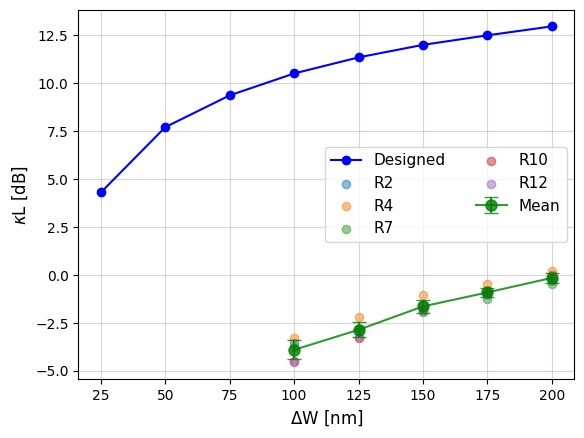

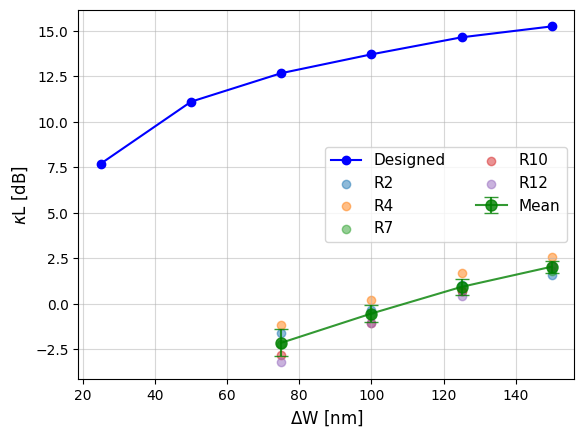

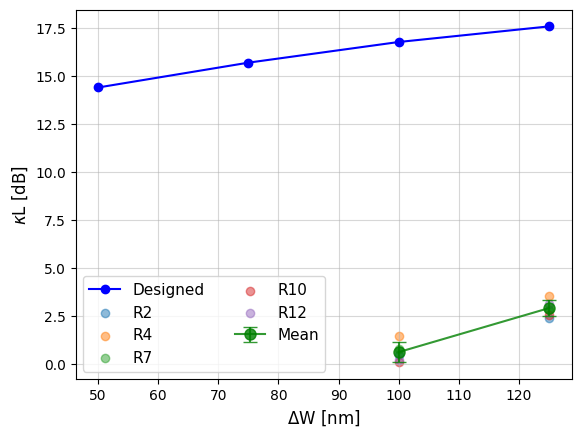

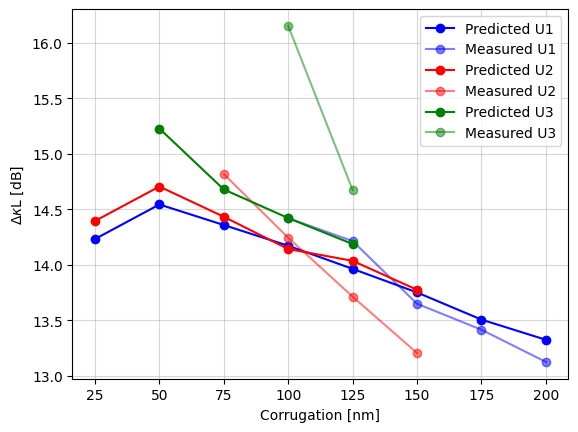

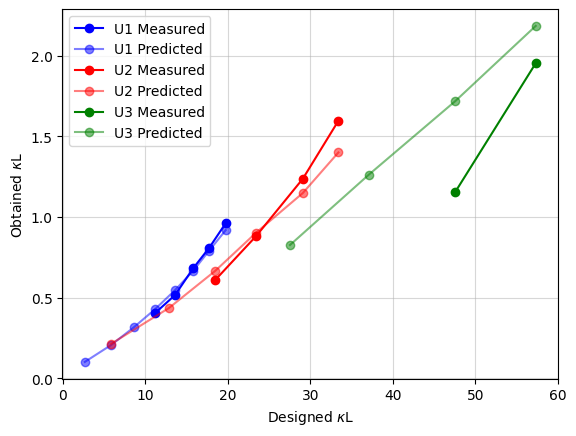

In [40]:
## U1 ##
plt.plot(dw_u1, 10*np.log10(kappaL_sim_u1), 'o-', color='b', label='Designed')
#plt.plot(dw_u1, 10*np.log10(kappaL_fab_u1), 'o-', color='r', label='Prediction')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
reticle = ['R2', 'R4', 'R7', 'R10', 'R12']

for i in range(len(kls_u1)):
    plt.scatter(dw_measure_u1, 10*np.log10(kls_u1[i]), color=colors[i], alpha=0.5, label=f'{reticle[i]}')

means_u1 = np.mean(kls_u1, axis=0)
stds_u1 = np.std(kls_u1, axis=0)
plt.errorbar(dw_measure_u1, 10*np.log10(means_u1), yerr=(10*stds_u1/means_u1)/np.log(10), fmt='o-', color='g', capsize=5, markersize=8, label='Mean', alpha=0.8)

plt.ylabel(r'$\kappa$L [dB]', fontsize=12)
plt.xlabel(r'$\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(ncols=2, fontsize=11)
#plt.savefig("U1_kappaL_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## U2 ##
plt.plot(dw_u2, 10*np.log10(kappaL_sim_u2), 'o-', color='b', label='Designed')
#plt.plot(dw_u2, 10*np.log10(kappaL_fab_u2), 'o-', color='r', label='Prediction')

for i in range(len(kls_u2)):
    plt.scatter(dw_measure_u2, 10*np.log10(kls_u2[i]), color=colors[i], alpha=0.5, label=f'{reticle[i]}')

means_u2 = np.mean(kls_u2, axis=0)
stds_u2 = np.std(kls_u2, axis=0)
plt.errorbar(dw_measure_u2, 10*np.log10(means_u2), yerr=(10*stds_u2/means_u2)/np.log(10), fmt='o-', color='g', capsize=5, markersize=8, label='Mean', alpha=0.8)

plt.ylabel(r'$\kappa$L [dB]', fontsize=12)
plt.xlabel(r'$\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(ncols=2, fontsize=11)
#plt.savefig("U2_kappaL_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## U3 ##
plt.plot(dw_u3, 10*np.log10(kappaL_sim_u3), 'o-', color='b', label='Designed')
#plt.plot(dw_u3, 10*np.log10(kappaL_fab_u3), 'o-', color='r', label='Prediction')

for i in range(len(kls_u3)):
    plt.scatter(dw_measure_u3, 10*np.log10(kls_u3[i]), color=colors[i], alpha=0.5, label=f'{reticle[i]}')

means_u3 = np.mean(kls_u3, axis=0)
stds_u3 = np.std(kls_u3, axis=0)
plt.errorbar(dw_measure_u3, 10*np.log10(means_u3), yerr=(10*stds_u3/means_u3)/np.log(10), fmt='o-', color='g', capsize=5, markersize=8, label='Mean', alpha=0.8)

plt.ylabel(r'$\kappa$L [dB]', fontsize=12)
plt.xlabel(r'$\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(ncols=2, fontsize=11)
#plt.savefig("U3_kappaL_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Overall ## 
plt.plot(dw_u1, 10*np.log10(kappaL_sim_u1/kappaL_fab_u1),  'o-', label='Predicted U1', color='b')
plt.plot(dw_measure_u1, 10*np.log10(kappaL_sim_u1[3:]/kls_mean_u1), 'o-', label='Measured U1', color='b', alpha=0.5)

plt.plot(dw_u2, 10*np.log10(kappaL_sim_u2/kappaL_fab_u2), 'o-', label='Predicted U2', color='r')
plt.plot(dw_measure_u2, 10*np.log10(kappaL_sim_u2[2:]/kls_mean_u2), 'o-', label='Measured U2', color='r', alpha=0.5)

plt.plot(dw_u3, 10*np.log10(kappaL_sim_u3/kappaL_fab_u3), 'o-', label='Predicted U3', color='g')
plt.plot(dw_measure_u3, 10*np.log10(kappaL_sim_u3[2:]/kls_mean_u3), 'o-', label='Measured U3', color='g', alpha=0.5)

plt.ylabel(r'$\Delta\kappa$L [dB]')
plt.xlabel('Corrugation [nm]')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

p2 = np.polyfit(kappaL_sim_u1, kappaL_fab_u1, 2)
x_fit = np.linspace(min(kappaL_sim_u1), max(kappaL_sim_u1), 100)
y_quad = np.polyval(p2, x_fit)

plt.plot(kappaL_sim_u1[3:], means_u1, 'o-',  color='b', label='U1 Measured')
plt.plot(kappaL_sim_u1, kappaL_fab_u1, 'o-', color='b', label='U1 Predicted', alpha=0.5)

plt.plot(kappaL_sim_u2[2:], means_u2, 'o-', color='r', label='U2 Measured')
plt.plot(kappaL_sim_u2, kappaL_fab_u2, 'o-', color='r', label='U2 Predicted', alpha=0.5)

plt.plot(kappaL_sim_u3[2:], means_u3, 'o-', color='g', label='U3 Measured')
plt.plot(kappaL_sim_u3, kappaL_fab_u3, 'o-', color='g', label='U3 Predicted', alpha=0.5)

plt.xlabel(r'Designed $\kappa$L')
plt.ylabel(r'Obtained $\kappa$L')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

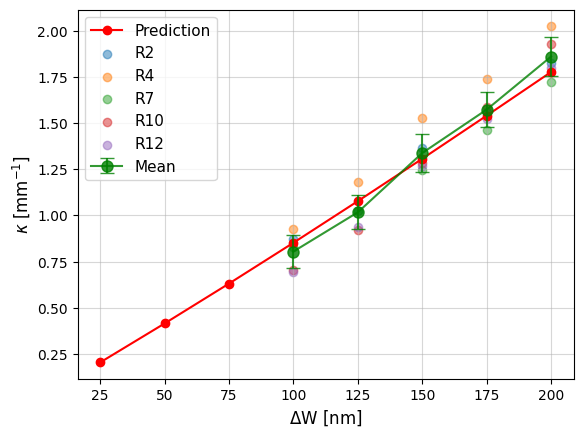

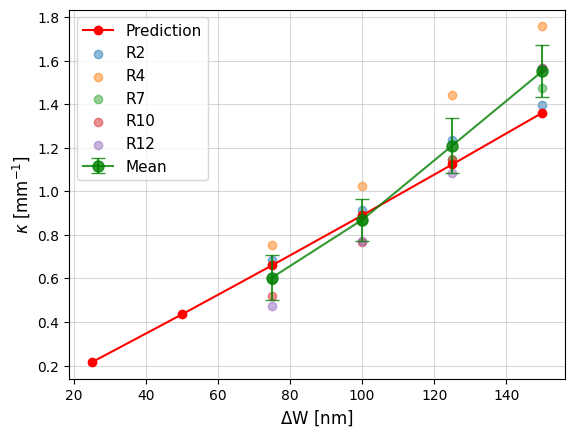

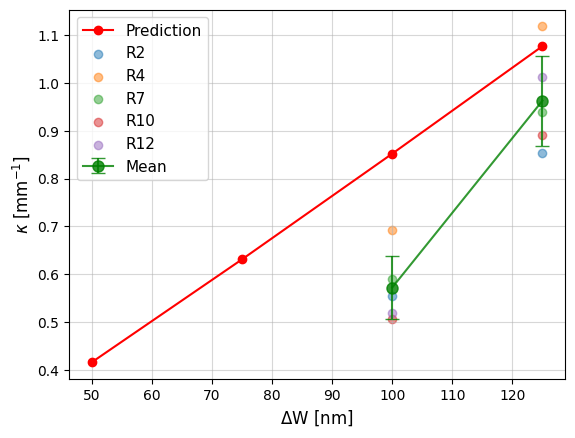

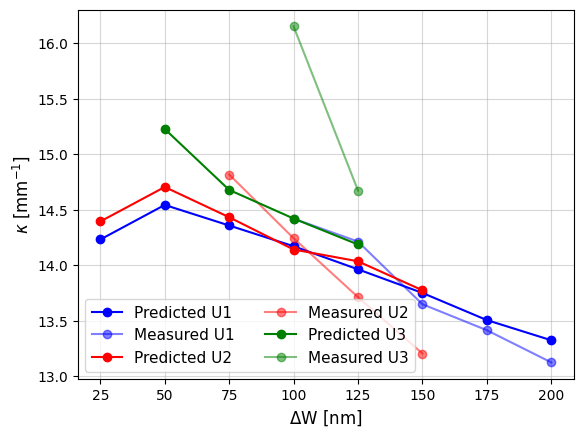

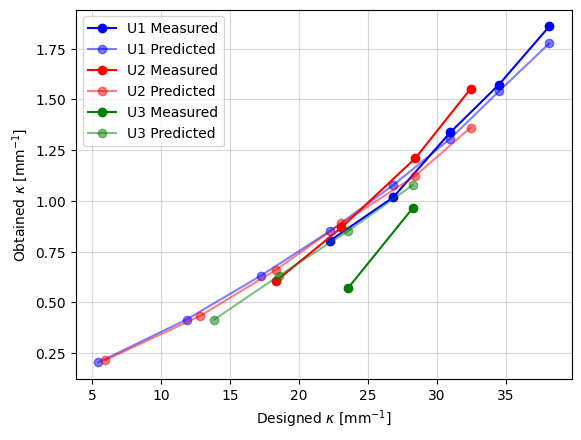

1.187e-02


In [ ]:
## U1 ##
#plt.plot(dw_u1, np.array(kappa_sim_u1)*1e-3, 'o-', color='b', label='Designed')
plt.plot(dw_u1, np.array(kappa_fab_u1)*1e-3, 'o-', color='r', label='Prediction')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
reticle = ['R2', 'R4', 'R7', 'R10', 'R12']

for i in range(len(ks_u1)):
    plt.scatter(dw_measure_u1, (ks_u1[i])*1e-3, color=colors[i], alpha=0.5, label=f'{reticle[i]}')

means_u1 = np.mean(ks_u1, axis=0)
stds_u1 = np.std(ks_u1, axis=0)
plt.errorbar(dw_measure_u1, (means_u1)*1e-3, yerr=stds_u1*1e-3, fmt='o-', color='g', capsize=5, markersize=8, label='Mean', alpha=0.8)

plt.ylabel(r'$\kappa$ [mm$^{-1}$]', fontsize=12)
plt.xlabel(r'$\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(ncols=1, fontsize=11)
#plt.savefig("U1_eval_kappa.png", dpi=300, bbox_inches="tight")
plt.show()

## U2 ##
#plt.plot(dw_u2, np.array(kappa_sim_u2)*1e-3, 'o-', color='b', label='Designed')
plt.plot(dw_u2, np.array(kappa_fab_u2)*1e-3, 'o-', color='r', label='Prediction')

for i in range(len(ks_u2)):
    plt.scatter(dw_measure_u2, (ks_u2[i])*1e-3, color=colors[i], alpha=0.5, label=f'{reticle[i]}')

means_u2 = np.mean(ks_u2, axis=0)
stds_u2 = np.std(ks_u2, axis=0)
plt.errorbar(dw_measure_u2, (means_u2)*1e-3, yerr=stds_u2*1e-3, fmt='o-', color='g', capsize=5, markersize=8, label='Mean', alpha=0.8)

plt.ylabel(r'$\kappa$ [mm$^{-1}$]', fontsize=12)
plt.xlabel(r'$\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(ncols=1, fontsize=11)
#plt.savefig("U2_eval_kappa.png", dpi=300, bbox_inches="tight")
plt.show()

## U3 ##
#plt.plot(dw_u3, np.array(kappa_sim_u3)*1e-3, 'o-', color='b', label='Designed')
plt.plot(dw_u3, np.array(kappa_fab_u3)*1e-3, 'o-', color='r', label='Prediction')

for i in range(len(ks_u3)):
    plt.scatter(dw_measure_u3, (ks_u3[i])*1e-3, color=colors[i], alpha=0.5, label=f'{reticle[i]}')

means_u3 = np.mean(ks_u3, axis=0)
stds_u3 = np.std(ks_u3, axis=0)
plt.errorbar(dw_measure_u3, (means_u3)*1e-3, yerr=stds_u3*1e-3, fmt='o-', color='g', capsize=5, markersize=8, label='Mean', alpha=0.8)

plt.ylabel(r'$\kappa$ [mm$^{-1}$]', fontsize=12)
plt.xlabel(r'$\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(ncols=1, fontsize=11)
#plt.savefig("U3_eval_kappa.png", dpi=300, bbox_inches="tight")
plt.show()

## Overall ## 
plt.plot(dw_u1, 10*np.log10(kappa_sim_u1/kappa_fab_u1),  'o-', label='Predicted U1', color='b')
plt.plot(dw_measure_u1, 10*np.log10(kappa_sim_u1[3:]/ks_mean_u1), 'o-', label='Measured U1', color='b', alpha=0.5)

plt.plot(dw_u2, 10*np.log10(kappa_sim_u2/kappa_fab_u2), 'o-', label='Predicted U2', color='r')
plt.plot(dw_measure_u2, 10*np.log10(kappa_sim_u2[2:]/ks_mean_u2), 'o-', label='Measured U2', color='r', alpha=0.5)

plt.plot(dw_u3, 10*np.log10(kappa_sim_u3/kappa_fab_u3), 'o-', label='Predicted U3', color='g')
plt.plot(dw_measure_u3, 10*np.log10(kappa_sim_u3[2:]/ks_mean_u3), 'o-', label='Measured U3', color='g', alpha=0.5)

plt.ylabel(r'$\kappa$ [mm$^{-1}$]', fontsize=12)
plt.xlabel(r'$\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(ncols=2, fontsize=11)
plt.show()


p2 = np.polyfit(kappa_sim_u1, kappa_fab_u1, 2)
x_fit = np.linspace(min(kappa_sim_u1), max(kappa_sim_u1), 100)
y_quad = np.polyval(p2, x_fit)

plt.plot(np.array(kappa_sim_u1[3:])*1e-3, means_u1*1e-3, 'o-',  color='b', label='U1 Measured')
plt.plot(np.array(kappa_sim_u1)*1e-3, np.array(kappa_fab_u1)*1e-3, 'o-', color='b', label='U1 Predicted', alpha=0.5)

plt.plot(np.array(kappa_sim_u2[2:])*1e-3, means_u2*1e-3, 'o-', color='r', label='U2 Measured')
plt.plot(np.array(kappa_sim_u2)*1e-3, np.array(kappa_fab_u2)*1e-3, 'o-', color='r', label='U2 Predicted', alpha=0.5)

plt.plot(np.array(kappa_sim_u3[2:])*1e-3, means_u3*1e-3, 'o-', color='g', label='U3 Measured')
plt.plot(np.array(kappa_sim_u3)*1e-3, np.array(kappa_fab_u3)*1e-3, 'o-', color='g', label='U3 Predicted', alpha=0.5)

plt.xlabel(r'Designed $\kappa$ [mm$^{-1}$]')
plt.ylabel(r'Obtained $\kappa$ [mm$^{-1}$]')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

rmse = np.sqrt(np.mean((np.array(kappa_fab_u2[2:])*1e-3 - means_u2*1e-3)**2))
print(f'{rmse:.3e}')

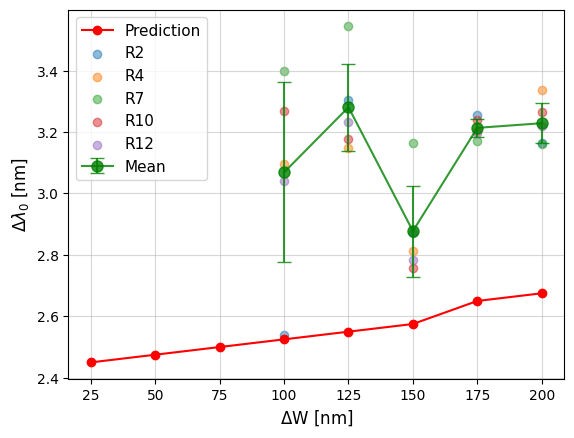

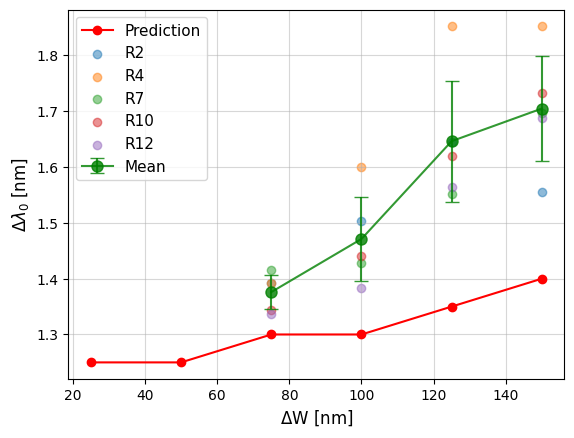

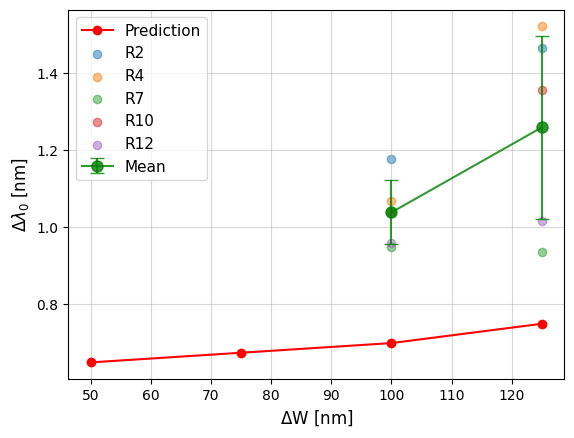

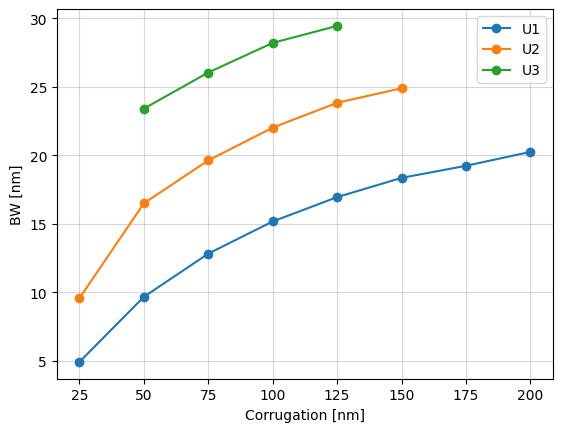

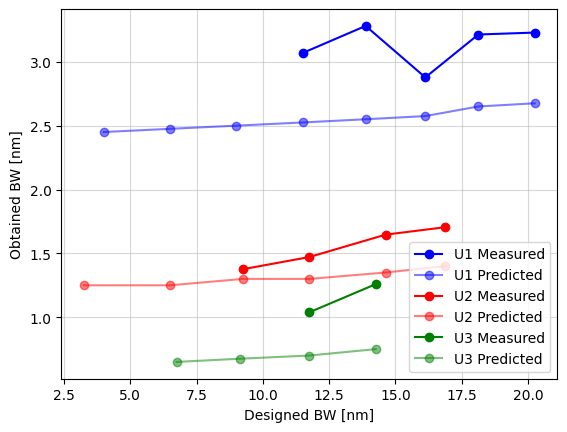

[0.005776   0.02930944 0.08785296 0.09290304]
5.396e-02


In [ ]:
## U1 ##
#plt.plot(dw_u1, np.array(bw_sim_u1)*1e9, '*-', color='b', label='Designed')
plt.plot(dw_u1, np.array(bw_fab_u1)*1e9, 'o-', color='r', label='Prediction')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
reticle = ['R2', 'R4', 'R7', 'R10', 'R12']

for i in range(len(bws_u1)):
    plt.scatter(dw_measure_u1, (bws_u1[i]), color=colors[i], alpha=0.5, label=f'{reticle[i]}')

means_u1 = np.mean(bws_u1, axis=0)
stds_u1 = np.std(bws_u1, axis=0)
plt.errorbar(dw_measure_u1, (means_u1), yerr=stds_u1, fmt='o-', color='g', capsize=5, markersize=8, label='Mean', alpha=0.8)

plt.ylabel(r'$\Delta \lambda_0$ [nm]', fontsize=12)
plt.xlabel(r'$\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(ncols=1, fontsize=11)
#plt.savefig("U1_eval_bw.png", dpi=300, bbox_inches="tight")
plt.show()

## U2 ##
#plt.plot(dw_u2, np.array(bw_sim_u2)*1e9, '*-', color='b', label='Designed')
plt.plot(dw_u2, np.array(bw_fab_u2)*1e9, 'o-', color='r', label='Prediction')

for i in range(len(bws_u2)):
    plt.scatter(dw_measure_u2, bws_u2[i], color=colors[i], alpha=0.5, label=f'{reticle[i]}')

means_u2 = np.mean(bws_u2, axis=0)
stds_u2 = np.std(bws_u2, axis=0)
plt.errorbar(dw_measure_u2, means_u2, yerr=stds_u2, fmt='o-', color='g', capsize=5, markersize=8, label='Mean', alpha=0.8)

plt.ylabel(r'$\Delta \lambda_0$ [nm]', fontsize=12)
plt.xlabel(r'$\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(ncols=1, fontsize=11)
#plt.savefig("U2_eval_bw.png", dpi=300, bbox_inches="tight")
plt.show()

## U3 ##
#plt.plot(dw_u3, np.array(bw_sim_u3)*1e9, '*-', color='b', label='Designed')
plt.plot(dw_u3, np.array(bw_fab_u3)*1e9, 'o-', color='r', label='Prediction')

for i in range(len(bws_u3)):
    plt.scatter(dw_measure_u3, bws_u3[i], color=colors[i], alpha=0.5, label=f'{reticle[i]}')

means_u3 = np.mean(bws_u3, axis=0)
stds_u3 = np.std(bws_u3, axis=0)
plt.errorbar(dw_measure_u3, means_u3, yerr=stds_u3, fmt='o-', color='g', capsize=5, markersize=8, label='Mean', alpha=0.8)

plt.ylabel(r'$\Delta \lambda_0$ [nm]', fontsize=12)
plt.xlabel(r'$\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(ncols=1, fontsize=11)
#plt.savefig("U3_eval_bw.png", dpi=300, bbox_inches="tight")
plt.show()

## Overall ## 
plt.plot(dw_u1, 10*np.log(bw_sim_u1/bw_fab_u1),  'o-', label='U1')
plt.plot(dw_u2, 10*np.log(bw_sim_u2/bw_fab_u2), 'o-', label='U2')
plt.plot(dw_u3, 10*np.log(bw_sim_u3/bw_fab_u3), 'o-', label='U3')

plt.ylabel('BW [nm]')
plt.xlabel('Corrugation [nm]')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

p2 = np.polyfit(bw_sim_u1, bw_fab_u1, 2)
x_fit = np.linspace(min(bw_sim_u1), max(bw_sim_u1), 100)
y_quad = np.polyval(p2, x_fit)

plt.plot(np.array(bw_sim_u1[3:])*1e9, means_u1, 'o-',  color='b', label='U1 Measured')
plt.plot(np.array(bw_sim_u1)*1e9, np.array(bw_fab_u1)*1e9, 'o-', color='b', label='U1 Predicted', alpha=0.5)

plt.plot(np.array(bw_sim_u2[2:])*1e9, means_u2, 'o-', color='r', label='U2 Measured')
plt.plot(np.array(bw_sim_u2)*1e9, np.array(bw_fab_u2)*1e9, 'o-', color='r', label='U2 Predicted', alpha=0.5)

plt.plot(np.array(bw_sim_u3[2:])*1e9, means_u3, 'o-', color='g', label='U3 Measured')
plt.plot(np.array(bw_sim_u3)*1e9, np.array(bw_fab_u3)*1e9, 'o-', color='g', label='U3 Predicted', alpha=0.5)

plt.xlabel(r'Designed BW [nm]')
plt.ylabel(r'Obtained BW [nm]')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

print((np.array(bw_fab_u2[2:])*1e9 - means_u2)**2)
rmse = np.sqrt(np.mean((np.array(bw_fab_u2[2:])*1e9 - means_u2)**2))
print(f'{rmse:.3e}')

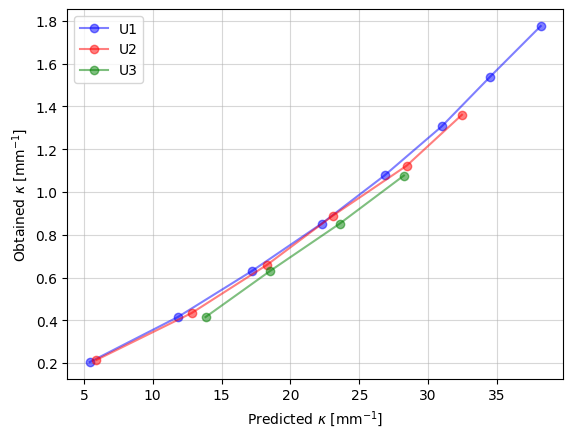

In [43]:
# Dispersion k designed vs k predicted/measured
p2 = np.polyfit(kappa_sim_u1, kappa_fab_u1, 2)
x_fit = np.linspace(min(kappa_sim_u1), max(kappa_sim_u1), 100)
y_quad = np.polyval(p2, x_fit)

#plt.plot(np.array(kappa_sim_u1[3:])*1e-3, means_u1*1e-3, 'o-',  color='b', label='U1')
plt.plot(np.array(kappa_sim_u1)*1e-3, np.array(kappa_fab_u1)*1e-3, 'o-', color='b', label='U1', alpha=0.5)

#plt.plot(np.array(kappa_sim_u2[2:])*1e-3, means_u2*1e-3, 'o-', color='r', label='U2')
plt.plot(np.array(kappa_sim_u2)*1e-3, np.array(kappa_fab_u2)*1e-3, 'o-', color='r', label='U2', alpha=0.5)

#plt.plot(np.array(kappa_sim_u3[2:])*1e-3, means_u3*1e-3, 'o-', color='g', label='U3')
plt.plot(np.array(kappa_sim_u3)*1e-3, np.array(kappa_fab_u3)*1e-3, 'o-', color='g', label='U3', alpha=0.5)

plt.xlabel(r'Predicted $\kappa$ [mm$^{-1}$]')
plt.ylabel(r'Obtained $\kappa$ [mm$^{-1}$]')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

## Test

test parameters 

λ   = [1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550 1550
 1550 1550] (nm)
ΔW  = [ 12.5  25.   37.5  50.   62.5  75.   87.5 100.  112.5 125.  137.5 150.
 162.5 175.  187.5 200. ] (nm)
Λ   = [507.12079317 506.63371849 506.1632861  505.70940593 505.2719913
 504.8509589  504.44622876 504.05772417 503.68537167 503.32910103
 502.98884517 502.66454019 502.35612529 502.06354274 501.7867379
 501.52565916] (nm)


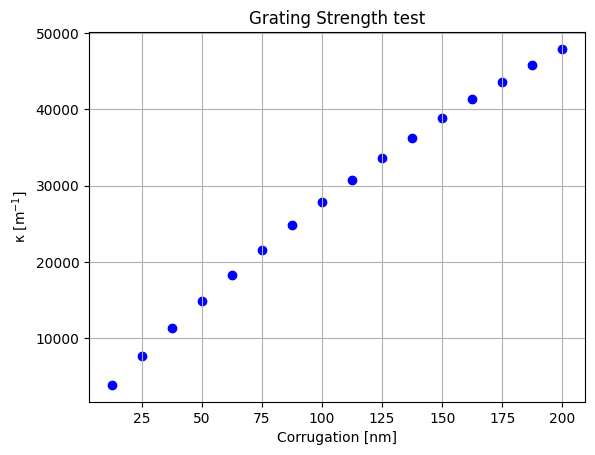

In [35]:
wl_test = np.array([1550]*16)
width_test = np.round(width_0 + np.arange(0, 17)*0.025, 3) # Waveguide width list (um)
dwidth_test = (width_test - width_0)/2 # Corrugation list (um)

# Obtain the grating period for each test Bragg grating
period_array_test = []
n1_array = []
n2_array = []
n_avg_test = []

i = 1 # Start with a corrugation of 25 nm
for bragg_wl in wl_test:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_test[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_test.append(float(n_avg))
    period_array_test.append(float(period*1e-3))
    i+=1

print('test parameters \n')
print(f'λ   = {wl_test} (nm)')
print(f'ΔW  = {(width_test[1:] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_test)*1e3} (nm)')

# Grating Strength
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_test = 2*delta_n/(wl_test*1e-9)
plt.scatter((width_test[1:] - width_0)/2*1e3, kappa_test, color='b')

plt.title('Grating Strength test')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

In [36]:
N_test_u1 = 1000

N = N_test_u1                                            # Number of periods of the design 
period_array = period_array_test                        # Array of periods
wl_array = wl_test                                      # Array of Bragg wavelengths
n_avg = n_avg_test                                    # Average refractive index array

# TMM Simulation
M_sim = n_sim*(2*N)

power_min_sim_test_u1 = []
wl_min_sim_test_u1 = []
bw_sim_test_u1 = []
kappa_sim_test_u1 = []
kappaL_sim_test_u1 = []
T_sim_tot_test_u1 = []
phi_r_sim_tot_test_u1 = []
phi_t_sim_tot_test_u1 = []

for i in range(len(period_array)):
    t_inicio = time.perf_counter()
    corrugation = dwidth_test[i+1]
    L = N*period_array[i]*1e-6
    dz = L/M_sim 
    
    z_real, dw_real_p, dw_real_n = uniform_grating(period_array[i] * 1e-6, corrugation, N, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_sim)
    w_mean = dw_mean_p - dw_mean_n + width_0

    wavelength_test0 = np.arange(wl_array[i] - window_size_sim, wl_array[i] + window_size_sim, 0.125)*1e-9

    M_wl = Bragg_grating(wavelength_test0, w_mean, dz, M_sim, popt_wl, popt_w)

    T_sim = []
    phi_r_sim = []
    phi_t_sim = []

    for j in range(len(wavelength_test0)):
        T_sim.append(1 / (np.abs(M_wl[j][0, 0]) ** 2))
        phi_r_sim.append(np.angle(1 / M_wl[j][0, 0]))
        phi_t_sim.append(np.angle(M_wl[j][1, 0] / M_wl[j][0, 0]))

    aux = wavelength_test0**2 / (2 * np.pi * 3e8)
    tau_r_sim = aux * np.gradient(np.unwrap(np.array(phi_r_sim)), wavelength_test0)
    tau_t_sim = aux * np.gradient(np.unwrap(np.array(phi_t_sim)), wavelength_test0)
    phi_r_sim = np.unwrap(phi_r_sim)
    phi_t_sim = np.unwrap(phi_t_sim)

    T_sim_tot_test_u1.append(T_sim)
    phi_r_sim_tot_test_u1.append(phi_r_sim)
    phi_t_sim_tot_test_u1.append(phi_t_sim)

    t_final = time.perf_counter()
    print(f'Execution Time Design {i}: {t_final - t_inicio:.2f} s')

    idx_min, wl_min = find_minima_sides(wavelength_test0, np.array(T_sim), distance=2)
    bw_sim_test_u1.append(np.abs(wavelength_test0[idx_min[0]] - wavelength_test0[idx_min[1]]))
    kappa_sim_test_u1.append(np.pi*np.sqrt((n_avg[i]*bw_sim_test_u1[i]/((wl_array[i]*1e-9)**2))**2 - 1/(L**2)))

    kappaL_sim_test_u1.append(kappa_sim_test_u1[i]*L)
    power_min_sim_test_u1.append(10*np.log10(min(T_sim)))
    wl_min_sim_test_u1.append(wavelength_test0[np.argmin(T_sim)]*1e9)

Execution Time Design 0: 4.05 s


/tmp/ipykernel_999/3299675144.py:58: RuntimeWarning: invalid value encountered in sqrt
  kappa_sim_test_u1.append(np.pi*np.sqrt((n_avg[i]*bw_sim_test_u1[i]/((wl_array[i]*1e-9)**2))**2 - 1/(L**2)))


Execution Time Design 1: 4.09 s
Execution Time Design 2: 4.04 s
Execution Time Design 3: 3.98 s
Execution Time Design 4: 3.97 s
Execution Time Design 5: 4.20 s
Execution Time Design 6: 4.30 s
Execution Time Design 7: 4.02 s
Execution Time Design 8: 3.96 s
Execution Time Design 9: 3.96 s
Execution Time Design 10: 4.00 s
Execution Time Design 11: 4.00 s
Execution Time Design 12: 3.96 s
Execution Time Design 13: 4.16 s
Execution Time Design 14: 4.22 s
Execution Time Design 15: 4.06 s


In [37]:
N_test_u2 = 2000

N = N_test_u2                                            # Number of periods of the design 
period_array = period_array_test                      # Array of periods
wl_array = wl_test                                    # Array of Bragg wavelengths
n_avg = n_avg_test                                    # Average refractive index array

# TMM Simulation
M_sim = n_sim*(2*N)

power_min_sim_test_u2 = []
wl_min_sim_test_u2 = []
bw_sim_test_u2 = []
kappa_sim_test_u2 = []
kappaL_sim_test_u2 = []
T_sim_tot_test_u2 = []
phi_r_sim_tot_test_u2 = []
phi_t_sim_tot_test_u2 = []

for i in range(len(period_array)):
    t_inicio = time.perf_counter()
    corrugation = dwidth_test[i+1]
    L = N*period_array[i]*1e-6
    dz = L/M_sim 
    
    z_real, dw_real_p, dw_real_n = uniform_grating(period_array[i] * 1e-6, corrugation, N, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_sim)
    w_mean = dw_mean_p - dw_mean_n + width_0

    wavelength_test0 = np.arange(wl_array[i] - window_size_sim, wl_array[i] + window_size_sim, 0.125)*1e-9

    M_wl = Bragg_grating(wavelength_test0, w_mean, dz, M_sim, popt_wl, popt_w)

    T_sim = []
    phi_r_sim = []
    phi_t_sim = []

    for j in range(len(wavelength_test0)):
        T_sim.append(1 / (np.abs(M_wl[j][0, 0]) ** 2))
        phi_r_sim.append(np.angle(1 / M_wl[j][0, 0]))
        phi_t_sim.append(np.angle(M_wl[j][1, 0] / M_wl[j][0, 0]))

    aux = wavelength_test0**2 / (2 * np.pi * 3e8)
    tau_r_sim = aux * np.gradient(np.unwrap(np.array(phi_r_sim)), wavelength_test0)
    tau_t_sim = aux * np.gradient(np.unwrap(np.array(phi_t_sim)), wavelength_test0)
    phi_r_sim = np.unwrap(phi_r_sim)
    phi_t_sim = np.unwrap(phi_t_sim)

    T_sim_tot_test_u2.append(T_sim)
    phi_r_sim_tot_test_u2.append(phi_r_sim)
    phi_t_sim_tot_test_u2.append(phi_t_sim)

    t_final = time.perf_counter()
    print(f'Execution Time Design {i}: {t_final - t_inicio:.2f} s')

    idx_min, wl_min = find_minima_sides(wavelength_test0, np.array(T_sim), distance=2)
    bw_sim_test_u2.append(np.abs(wavelength_test0[idx_min[0]] - wavelength_test0[idx_min[1]]))
    kappa_sim_test_u2.append(np.pi*np.sqrt((n_avg[i]*bw_sim_test_u2[i]/((wl_array[i]*1e-9)**2))**2 - 1/(L**2)))

    kappaL_sim_test_u2.append(kappa_sim_test_u2[i]*L)
    power_min_sim_test_u2.append(10*np.log10(min(T_sim)))
    wl_min_sim_test_u2.append(wavelength_test0[np.argmin(T_sim)]*1e9)

Execution Time Design 0: 9.05 s
Execution Time Design 1: 9.12 s
Execution Time Design 2: 9.42 s
Execution Time Design 3: 9.09 s
Execution Time Design 4: 9.01 s
Execution Time Design 5: 9.26 s
Execution Time Design 6: 9.36 s
Execution Time Design 7: 8.97 s
Execution Time Design 8: 9.01 s
Execution Time Design 9: 9.48 s
Execution Time Design 10: 9.28 s
Execution Time Design 11: 9.50 s
Execution Time Design 12: 9.52 s
Execution Time Design 13: 9.44 s
Execution Time Design 14: 9.01 s
Execution Time Design 15: 8.98 s


[  0.  25.  50.  75. 100. 125. 150. 175. 200.]
test parameters 

λ   = [1550 1550 1550 1550 1550 1550 1550 1550] (nm)
ΔW  = [ 25.  50.  75. 100. 125. 150. 175. 200.] (nm)
Λ   = [506.63371849 505.70940593 504.8509589  504.05772417 503.32910103
 502.66454019 502.06354274 501.52565916] (nm)


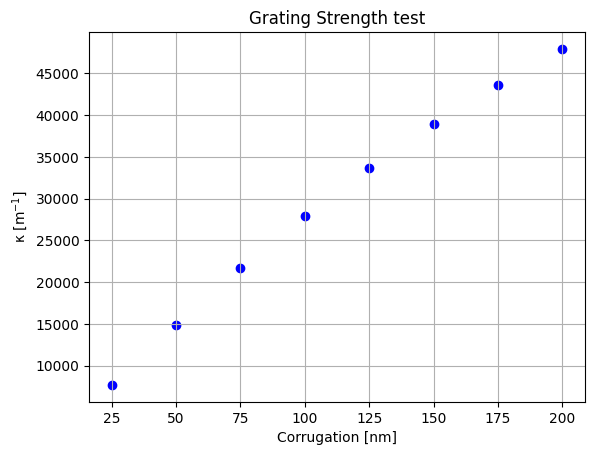

In [38]:
wl_test_u3 = np.array([1550]*8)
width_test_u3= np.round(width_0 + np.arange(0, 9)*0.05, 3) # Waveguide width list (um)
dwidth_test_u3= (width_test_u3- width_0)/2 # Corrugation list (um)
print(dwidth_test_u3*1e3)

# Obtain the grating period for each test Bragg grating
period_array_test_u3= []
n1_array = []
n2_array = []
n_avg_test_u3= []

i = 1 
for bragg_wl in wl_test_u3:
    neff_1 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_0, *popt_w)
    neff_2 = neff_wl(bragg_wl, *popt_wl) + dneff_w(width_test_u3[i], *popt_w)

    n_avg = (neff_1 + neff_2)/2
    period = bragg_wl/(2*n_avg)

    n1_array.append(float(neff_1))
    n2_array.append(float(neff_2))
    n_avg_test_u3.append(float(n_avg))
    period_array_test_u3.append(float(period*1e-3))
    i+=1

print('test parameters \n')
print(f'λ   = {wl_test_u3} (nm)')
print(f'ΔW  = {(width_test_u3[1:] - width_0)/2*1e3} (nm)')
print(f'Λ   = {np.array(period_array_test_u3)*1e3} (nm)')

# Grating Strength
delta_n = np.array(n2_array) - np.array(n1_array)
kappa_test_u3 = 2*delta_n/(wl_test_u3*1e-9)
plt.scatter((width_test_u3[1:] - width_0)/2*1e3, kappa_test_u3, color='b')

plt.title('Grating Strength test')
plt.ylabel(r'κ [m$^{-1}$]')
plt.xlabel('Corrugation [nm]')
plt.grid()
plt.show()

In [39]:
N_test_u3 = 4000

N = N_test_u3                                            # Number of periods of the design 
period_array = period_array_test_u3                     # Array of periods
wl_array = wl_test_u3                                    # Array of Bragg wavelengths
n_avg = n_avg_test_u3                                   # Average refractive index array

# TMM Simulation
M_sim = n_sim*(2*N)

power_min_sim_test_u3 = []
wl_min_sim_test_u3 = []
bw_sim_test_u3 = []
kappa_sim_test_u3 = []
kappaL_sim_test_u3 = []
T_sim_tot_test_u3 = []
phi_r_sim_tot_test_u3 = []
phi_t_sim_tot_test_u3 = []

for i in range(len(period_array)):
    t_inicio = time.perf_counter()
    corrugation = dwidth_test_u3[i+1]
    L = N*period_array[i]*1e-6
    dz = L/M_sim 
    
    z_real, dw_real_p, dw_real_n = uniform_grating(period_array[i] * 1e-6, corrugation, N, duty=0.5, dL=0)
    z_edges, dw_mean_p, dw_mean_n = grating_geometry(z_real, dw_real_p, dw_real_n, M_sim)
    w_mean = dw_mean_p - dw_mean_n + width_0

    wavelength_test0 = np.arange(wl_array[i] - window_size_sim, wl_array[i] + window_size_sim, 0.125)*1e-9

    M_wl = Bragg_grating(wavelength_test0, w_mean, dz, M_sim, popt_wl, popt_w)

    T_sim = []
    phi_r_sim = []
    phi_t_sim = []

    for j in range(len(wavelength_test0)):
        T_sim.append(1 / (np.abs(M_wl[j][0, 0]) ** 2))
        phi_r_sim.append(np.angle(1 / M_wl[j][0, 0]))
        phi_t_sim.append(np.angle(M_wl[j][1, 0] / M_wl[j][0, 0]))

    aux = wavelength_test0**2 / (2 * np.pi * 3e8)
    tau_r_sim = aux * np.gradient(np.unwrap(np.array(phi_r_sim)), wavelength_test0)
    tau_t_sim = aux * np.gradient(np.unwrap(np.array(phi_t_sim)), wavelength_test0)
    phi_r_sim = np.unwrap(phi_r_sim)
    phi_t_sim = np.unwrap(phi_t_sim)

    T_sim_tot_test_u3.append(T_sim)
    phi_r_sim_tot_test_u3.append(phi_r_sim)
    phi_t_sim_tot_test_u3.append(phi_t_sim)

    t_final = time.perf_counter()
    print(f'Execution Time Design {i}: {t_final - t_inicio:.2f} s')

    idx_min, wl_min = find_minima_sides(wavelength_test0, np.array(T_sim), distance=2)
    bw_sim_test_u3.append(np.abs(wavelength_test0[idx_min[0]] - wavelength_test0[idx_min[1]]))
    kappa_sim_test_u3.append(np.pi*np.sqrt((n_avg[i]*bw_sim_test_u3[i]/((wl_array[i]*1e-9)**2))**2 - 1/(L**2)))

    kappaL_sim_test_u3.append(kappa_sim_test_u3[i]*L)
    power_min_sim_test_u3.append(10*np.log10(min(T_sim)))
    wl_min_sim_test_u3.append(wavelength_test0[np.argmin(T_sim)]*1e9)

Execution Time Design 0: 26.13 s
Execution Time Design 1: 25.27 s
Execution Time Design 2: 25.85 s
Execution Time Design 3: 25.79 s
Execution Time Design 4: 26.27 s
Execution Time Design 5: 25.96 s
Execution Time Design 6: 26.12 s
Execution Time Design 7: 25.93 s


Ecuación ajustada: y = -3.495e-05*x^2 + 3.918e-02*x
0.016272541115692183
alpha = 25.526397670398886
Ecuación ajustada: y = 6.317e-05*x^2 + 3.517e-02*x
0.017759018966286455
alpha = 28.433555010208
Ecuación ajustada: y = 1.410e-04*x^2 + 3.239e-02*x
0.013244400080781411
alpha = 30.877603076738353


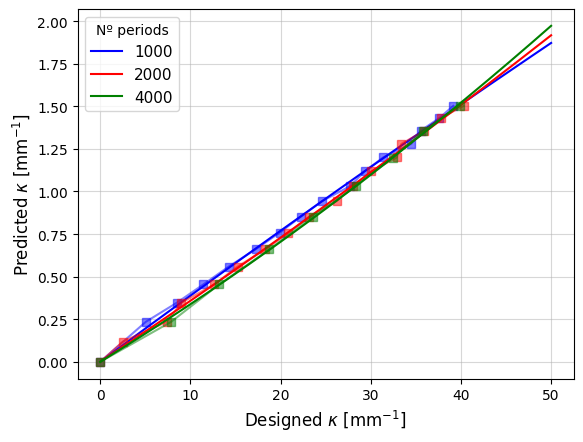

In [40]:
# Dispersion k designed vs k predicted/measured
design_test_u1, bw_fab_test_u1, power_min_fab_test_u1, kappaL_fab_test_u1, kappa_fab_test_u1, wl_min_fab_test_u1 = (
    pd.read_csv(f'/home/arjoa/UPVfab/upvfab-design-tools/examples/Test Results/U1_test_parameters.csv').to_numpy().T)

design_test_u2, bw_fab_test_u2, power_min_fab_test_u2, kappaL_fab_test_u2, kappa_fab_test_u2, wl_min_fab_test_u2 = (
    pd.read_csv(f'/home/arjoa/UPVfab/upvfab-design-tools/examples/Test Results/U2_test_parameters.csv').to_numpy().T)

design_test_u3, bw_fab_test_u3, power_min_fab_test_u3, kappaL_fab_test_u3, kappa_fab_test_u3, wl_min_fab_test_u3 = (
    pd.read_csv(f'/home/arjoa/UPVfab/upvfab-design-tools/examples/Test Results/U3_test_parameters.csv').to_numpy().T)

x_fit = np.linspace(0, 50, 1000)

def dependency_fit(x, a, b):
    return a*x**2 + b*x

# U1
kappa_sim_test_u1_buff = [0.0] + kappa_sim_test_u1[1:]
kappa_fab_test_u1_buff = np.insert(kappa_fab_test_u1[1:], 0, 0.0)

popt_u1, _ = curve_fit(dependency_fit, np.array(kappa_sim_test_u1_buff)*1e-3, np.array(kappa_fab_test_u1_buff)*1e-3)
p_u1 = np.poly1d(popt_u1)
y_quad_u1 = dependency_fit(x_fit, *popt_u1)
print(f"Ecuación ajustada: y = {popt_u1[0]:.3e}*x^2 + {popt_u1[1]:.3e}*x")
y_quad0_u1 = dependency_fit(np.array(kappa_sim_test_u1_buff)*1e-3, *popt_u1)
rmse_u1 = np.sqrt(np.mean((np.array(kappa_fab_test_u1_buff)*1e-3 - y_quad0_u1)**2))
print(f'{rmse_u1}')
print(f'alpha = {1/popt_u1[1]}')

plt.plot(np.array(kappa_sim_test_u1_buff)*1e-3, np.array(kappa_fab_test_u1_buff)*1e-3, color='b', alpha=0.5, marker='s')
plt.plot(x_fit, y_quad_u1, color='b', label='1000')

# U2
kappa_sim_test_u2_buff = [0.0] + kappa_sim_test_u2
kappa_fab_test_u2_buff = np.insert(kappa_fab_test_u2, 0, 0.0)

popt_u2, _ = curve_fit(dependency_fit, np.array(kappa_sim_test_u2)*1e-3, np.array(kappa_fab_test_u2)*1e-3)
p_u2 = np.poly1d(popt_u2)
y_quad_u2 = dependency_fit(x_fit, *popt_u2)
print(f"Ecuación ajustada: y = {popt_u2[0]:.3e}*x^2 + {popt_u2[1]:.3e}*x")
y_quad0_u2 = dependency_fit(np.array(kappa_sim_test_u2_buff)*1e-3, *popt_u2)
rmse_u2 = np.sqrt(np.mean((np.array(kappa_fab_test_u2_buff)*1e-3 - y_quad0_u2)**2))
print(f'{rmse_u2}')
print(f'alpha = {1/popt_u2[1]}')

plt.plot(np.array(kappa_sim_test_u2_buff)*1e-3, np.array(kappa_fab_test_u2_buff)*1e-3, color='r', alpha=0.5, marker='s')
plt.plot(x_fit, y_quad_u2, color='r', label='2000')

# U2
kappa_sim_test_u3_buff = [0.0] + kappa_sim_test_u3
kappa_fab_test_u3_buff = np.insert(kappa_fab_test_u3, 0, 0.0)

popt_u3, _ = curve_fit(dependency_fit, np.array(kappa_sim_test_u3_buff)*1e-3, np.array(kappa_fab_test_u3_buff)*1e-3)
p_u3 = np.poly1d(popt_u3)
y_quad_u3 = dependency_fit(x_fit, *popt_u3)
print(f"Ecuación ajustada: y = {popt_u3[0]:.3e}*x^2 + {popt_u3[1]:.3e}*x")
y_quad0_u3 = dependency_fit(np.array(kappa_sim_test_u3)*1e-3, *popt_u3)
rmse_u3 = np.sqrt(np.mean((np.array(kappa_fab_test_u3)*1e-3 - y_quad0_u3)**2))
print(f'{rmse_u3}')
print(f'alpha = {1/popt_u3[1]}')

plt.plot(np.array(kappa_sim_test_u3_buff)*1e-3, np.array(kappa_fab_test_u3_buff)*1e-3, color='g', alpha=0.5, marker='s')
plt.plot(x_fit, y_quad_u3, color='g', label='4000')

#plt.title(f'mse_U1={mse_u1_2:.3e}, {mse_u2_2:.3e}, {mse_u3_2:.3e}', fontsize=12)
plt.xlabel(r'Designed $\kappa$ [mm$^{-1}$]', fontsize=12)
plt.ylabel(r'Predicted $\kappa$ [mm$^{-1}$]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(fontsize=11, title='Nº periods')
plt.savefig("kappa_dependency2.png", dpi=300, bbox_inches="tight")
plt.show()


Ecuación ajustada: y = -1.031e-05*x^2 + 9.558e-03*x
0.0016559197228411518


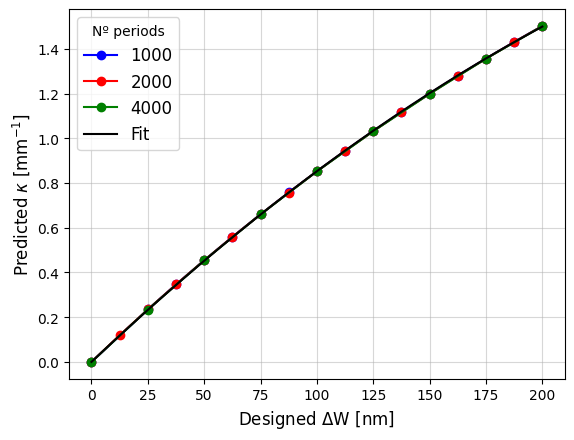

Ecuación ajustada: y = -2.449e-04*x^2 + 2.470e-01*x
0.41223080503994075
Ecuación ajustada: y = -3.472e-04*x^2 + 2.676e-01*x
0.4726984970247094
Ecuación ajustada: y = -4.177e-04*x^2 + 2.803e-01*x
0.45769586246672955


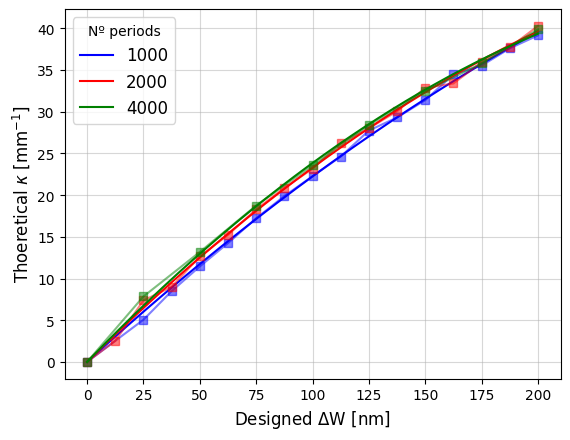

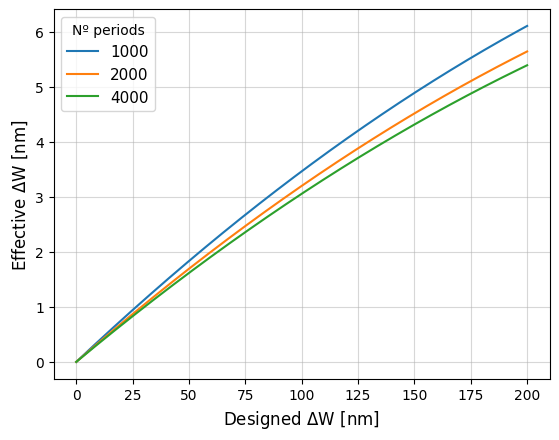

In [41]:
x_fit = np.linspace(0, 200, 2000)

def dependency_fit2(x, a, b):
    return a*x**2 + b*x

dwidth_test_buff_u1 = np.insert(dwidth_test[2:], 0, 0.0)
dwidth_test_buff_u2 = np.insert(dwidth_test[1:], 0, 0.0)
dwidth_test_buff_u3 = np.insert(dwidth_test_u3[1:], 0, 0.0)

### Experimental ###
popt_u1, _ = curve_fit(dependency_fit2, dwidth_test_buff_u1*1e3, np.array(kappa_fab_test_u1_buff)*1e-3)
p_u1 = np.poly1d(popt_u1)
y_quad_exp = dependency_fit2(x_fit, *popt_u1)
print(f"Ecuación ajustada: y = {popt_u1[0]:.3e}*x^2 + {popt_u1[1]:.3e}*x")
y_quad0_u1 = dependency_fit(dwidth_test_buff_u1*1e3, *popt_u1)
rmse_u1 = np.sqrt(np.mean((np.array(kappa_fab_test_u1_buff)*1e-3 - y_quad0_u1)**2))
print(f'{rmse_u1}')

# U1
plt.plot(dwidth_test_buff_u1*1e3, np.array(kappa_fab_test_u1_buff)*1e-3, color='b', marker='o', label='1000')

# U2
plt.plot(dwidth_test_buff_u2*1e3, np.array(kappa_fab_test_u2_buff)*1e-3, color='r', marker='o', label='2000')

# U2
plt.plot(dwidth_test_buff_u3*1e3, np.array(kappa_fab_test_u3_buff)*1e-3, color='g', marker='o', label='4000')

plt.plot(x_fit, y_quad_exp, color = 'black', label='Fit')

#plt.title(f'mse_U1={mse_u1_2:.3e}, {mse_u2_2:.3e}, {mse_u3_2:.3e}', fontsize=12)
plt.xlabel(r'Designed $\Delta$W [nm]', fontsize=12)
plt.ylabel(r'Predicted $\kappa$ [mm$^{-1}$]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(fontsize=12, title='Nº periods')
#plt.savefig("k_dw_exp.png", dpi=300, bbox_inches="tight")
plt.show()

### Theoretical ###
# U1
popt_u1, _ = curve_fit(dependency_fit2, dwidth_test_buff_u1*1e3, np.array(kappa_sim_test_u1_buff)*1e-3)
p_u1 = np.poly1d(popt_u1)
y_quad_u1 = dependency_fit2(x_fit, *popt_u1)
print(f"Ecuación ajustada: y = {popt_u1[0]:.3e}*x^2 + {popt_u1[1]:.3e}*x")
y_quad0_u1 = dependency_fit(dwidth_test_buff_u1*1e3, *popt_u1)
rmse_u1 = np.sqrt(np.mean((np.array(kappa_sim_test_u1_buff)*1e-3 - y_quad0_u1)**2))
print(f'{rmse_u1}')

plt.plot(dwidth_test_buff_u1*1e3, np.array(kappa_sim_test_u1_buff)*1e-3, color='b', marker='s', alpha=0.5)
plt.plot(x_fit, y_quad_u1, color = 'b', label='1000')

# U2
popt_u2, _ = curve_fit(dependency_fit2, dwidth_test_buff_u2*1e3, np.array(kappa_sim_test_u2_buff)*1e-3)
p_u2 = np.poly1d(popt_u2)
y_quad_u2 = dependency_fit2(x_fit, *popt_u2)
print(f"Ecuación ajustada: y = {popt_u2[0]:.3e}*x^2 + {popt_u2[1]:.3e}*x")
y_quad0_u2 = dependency_fit(dwidth_test_buff_u2*1e3, *popt_u2)
rmse_u2 = np.sqrt(np.mean((np.array(kappa_sim_test_u2_buff)*1e-3 - y_quad0_u2)**2))
print(f'{rmse_u2}')

plt.plot(dwidth_test_buff_u2*1e3, np.array(kappa_sim_test_u2_buff)*1e-3, color='r', marker='s', alpha=0.5)
plt.plot(x_fit, y_quad_u2, color = 'r', label='2000')

# U3
popt_u3, _ = curve_fit(dependency_fit2, dwidth_test_buff_u3*1e3, np.array(kappa_sim_test_u3_buff)*1e-3)
p_u3 = np.poly1d(popt_u3)
y_quad_u3 = dependency_fit2(x_fit, *popt_u3)
print(f"Ecuación ajustada: y = {popt_u3[0]:.3e}*x^2 + {popt_u3[1]:.3e}*x")
y_quad0_u3 = dependency_fit(dwidth_test_buff_u3*1e3, *popt_u3)
rmse_u3 = np.sqrt(np.mean((np.array(kappa_sim_test_u3_buff)*1e-3 - y_quad0_u3)**2))
print(f'{rmse_u3}')

plt.plot(dwidth_test_buff_u3*1e3, np.array(kappa_sim_test_u3_buff)*1e-3, color='g', marker='s', alpha=0.5)
plt.plot(x_fit, y_quad_u3, color = 'g', label='4000')

#plt.plot(x_fit, y_quad_exp, color = 'black', label='Predicted')
#plt.title(f'mse_U1={mse_u1_2:.3e}, {mse_u2_2:.3e}, {mse_u3_2:.3e}', fontsize=12)
plt.xlabel(r'Designed $\Delta$W [nm]', fontsize=12)
plt.ylabel(r'Thoeretical $\kappa$ [mm$^{-1}$]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(fontsize=12, title='Nº periods')
#plt.savefig("k_dw_theo.png", dpi=300, bbox_inches="tight")
plt.show()

### Corrugation dependency ###
x_u1 = np.interp(y_quad_exp, y_quad_u1, x_fit)
x_u2 = np.interp(y_quad_exp, y_quad_u2, x_fit)
x_u3 = np.interp(y_quad_exp, y_quad_u3, x_fit)

plt.plot(x_fit, x_u1, label='1000')
plt.plot(x_fit, x_u2, label='2000')
plt.plot(x_fit, x_u3, label='4000')
plt.xlabel(r'Designed $\Delta$W [nm]', fontsize=12)
plt.ylabel(r'Effective $\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(fontsize=11, title='Nº periods')
#plt.savefig("kappa_dependency.png", dpi=300, bbox_inches="tight")
plt.show()


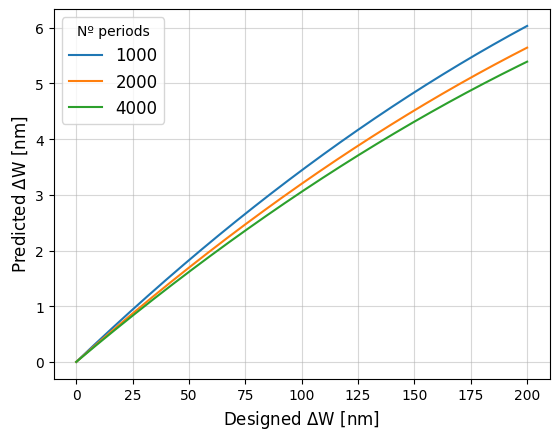

In [42]:
p_u1 = 2.449e-04; q_u1 = 2.470e-01
p_u2 = -3.472e-04; q_u2 = 2.676e-01
p_u3 = -4.177e-04; q_u3 = 2.803e-01
p_exp = -1.031e-05; q_exp = 9.558e-03

def test_f(dw, p_u, q_u):
    k_exp = p_exp*dw**2 + q_exp*dw
    root = np.sqrt(q_u**2 + 4*p_u*k_exp)
    return (-q_u + root)/(2*p_u)


plt.plot(x_fit, test_f(x_fit, p_u1, q_u1), label='1000')
plt.plot(x_fit, test_f(x_fit, p_u2, q_u2), label='2000')
plt.plot(x_fit, test_f(x_fit, p_u3, q_u3), label='4000')

plt.xlabel(r'Designed $\Delta$W [nm]', fontsize=12)
plt.ylabel(r'Predicted $\Delta$W [nm]', fontsize=12)
plt.grid(alpha=0.5)
plt.legend(fontsize=12, title='Nº periods')
#plt.savefig("dw_dependency.png", dpi=300, bbox_inches="tight")
plt.show()